<a href="https://colab.research.google.com/github/CD-GRUPO3/TA047R-1C2025-GRUPO03/blob/main/TA047R_TP1_GRUPO03_ENTREGA_EJ3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Grupo 3 - Ejercicio 3: *Regresión*
**Objetivo:** usar datos de alojamientos de la plataforma AirBnB, para predecir el precio de alquiler de una propiedad (price) en función de los datos publicados en el aviso.

**Integrantes:**
- ARIAS, Rafaela Pilar. 112272. rparias@fi.uba.ar.
- BARCALA ROCA, Ramiro. 112478. rbarcala@fi.uba.ar.
- LEMA, Mora. 111831. molema@fi.uba.ar.
- IENCO, Lara Eliana. 111921. lienco@fi.uba.ar.


EJ3: Rio de Janeiro
___

####Bibliografía:
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

###Inicialización del entorno
####Importamos todas las librerías que vamos a necesitar

In [ ]:
import pandas as pd #Manipulación y análisis de datos
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
!pip install tabulate
from tabulate import tabulate

from sklearn.linear_model import LinearRegression #Regresión lineal
#Metricas para evaluar modelos
from sklearn import metrics
#Para el preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_recall_curve, roc_curve, recall_score, accuracy_score,f1_score

#Configurar Pandas para que no use notación científica (CUALQUIER COSA ELIMINAR!!)
pd.set_option('display.float_format', '{:.6f}'.format)
pd.set_option('display.float_format', '{:,.0f}'.format)

###Cargamos el dataset sobre el cual vamos a trabajar

In [ ]:
#Listings
!gdown 11zEq7LHP5KwCGdj7ftTWf5X5pn37mgr6


Downloading...
From: https://drive.google.com/uc?id=11zEq7LHP5KwCGdj7ftTWf5X5pn37mgr6
To: /content/listings.csv
100% 79.0M/79.0M [00:01<00:00, 69.9MB/s]


In [ ]:
data = pd.read_csv('listings.csv')


#EJ 3: Regresión
---
##a) Análisis exploratorio
Se realiza un un acercamiento inicial general del dataset observando sus distintas características principales.

In [ ]:
data.shape

(39499, 75)

Tiene 39.499 filas y 75 columnas

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39499 entries, 0 to 39498
Data columns (total 75 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            39499 non-null  int64  
 1   listing_url                                   39499 non-null  object 
 2   scrape_id                                     39499 non-null  int64  
 3   last_scraped                                  39499 non-null  object 
 4   source                                        39499 non-null  object 
 5   name                                          39499 non-null  object 
 6   description                                   38379 non-null  object 
 7   neighborhood_overview                         16880 non-null  object 
 8   picture_url                                   39499 non-null  object 
 9   host_id                                       39499 non-null 

| Nombre de la Columna                | Tipo de Dato | Descripción                                                                                                                                                                 |
|-------------------------------------|--------------|-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| id                                  | entero       | Identificador único de Airbnb para el anuncio                                                                                                                                |
| listing_url                         | texto        | URL del anuncio de Airbnb                                                                                                                                                    |
| scrape_id                           | bigint       | Identificador dentro del "Scrape" de Inside Airbnb                                                                                                                           |
| last_scraped                        | datetime     | Fecha y hora en UTC cuando este anuncio fue "scrapeado"                                                                                                                      |
| source                              | texto        | Indica la fuente del anuncio: "neighbourhood search" o "previous scrape".                                                                                                    |
| name                                | texto        | Nombre del anuncio                                                                                                                                                           |
| description                         | texto        | Descripción detallada del anuncio                                                                                                                                             |
| neighborhood_overview               | texto        | Descripción del vecindario por parte del anfitrión                                                                                                                            |
| picture_url                         | texto        | URL de la imagen de tamaño regular alojada en Airbnb para el anuncio                                                                                                          |
| host_id                             | entero       | Identificador único de Airbnb para el anfitrión/usuario                                                                                                                      |
| host_url                            | texto        | URL del perfil del anfitrión en Airbnb                                                                                                                                         |
| host_name                           | texto        | Nombre del anfitrión (generalmente su primer nombre)                                                                                                                          |
| host_since                          | fecha        | Fecha en que el anfitrión/usuario se unió a Airbnb                                                                                                                            |
| host_location                       | texto        | Ubicación autoinformada del anfitrión                                                                                                                                         |
| host_about                          | texto        | Descripción sobre el anfitrión                                                                                                                                               |
| host_response_time                  | texto        | Tiempo que tarda el anfitrión en responder a las solicitudes de reserva                                                                                                      |
| host_response_rate                  | numérico     | Porcentaje de respuestas del anfitrión a los mensajes                                                                                                                         |
| host_acceptance_rate                | numérico     | Porcentaje de aceptación de solicitudes de reserva del anfitrión                                                                                                            |
| host_is_superhost                   | booleano     | Indica si el anfitrión es un Superhost (t=true; f=false)                                                                                                                      |
| host_thumbnail_url                  | texto        | URL de la imagen de miniatura del anfitrión                                                                                                                                   |
| host_picture_url                    | texto        | URL de la imagen del anfitrión                                                                                                                                               |
| host_neighbourhood                  | texto        | Vecindario del anfitrión                                                                                                                                                    |
| host_listings_count                 | texto        | Número de anuncios que tiene el anfitrión                                                                                                                                     |
| host_total_listings_count           | texto        | Número total de anuncios que tiene el anfitrión                                                                                                                              |
| host_verifications                  | texto        | Verificaciones del anfitrión (por ejemplo, correo electrónico, número de teléfono, etc.)                                                                                       |
| host_has_profile_pic                | booleano     | Indica si el anfitrión tiene foto de perfil (t=true; f=false)                                                                                                                |
| host_identity_verified              | booleano     | Indica si la identidad del anfitrión está verificada (t=true; f=false)                                                                                                       |
| neighbourhood                       | texto        | Vecindario del anuncio                                                                                                                                                      |
| neighbourhood_cleansed              | texto        | Nombre limpio del vecindario                                                                                                                                                 |
| neighbourhood_group_cleansed        | texto        | Nombre limpio del grupo de vecindarios                                                                                                                                       |
| latitude                            | numérico     | Latitud del anuncio (proyección WGS84)                                                                                                                                       |
| longitude                           | numérico     | Longitud del anuncio (proyección WGS84)                                                                                                                                      |
| property_type                       | texto        | Tipo de propiedad autoseleccionado (por ejemplo, apartamento, casa, etc.)                                                                                                   |
| room_type                           | texto        | Tipo de habitación (Apartamento/entero, Habitación privada, Habitación compartida o Hotel)                                                                                   |
| accommodates                        | entero       | Número máximo de personas que el anuncio puede acomodar                                                                                                                      |
| bathrooms                           | numérico     | Número de baños en el anuncio                                                                                                                                               |
| bathrooms_text                      | texto        | Descripción textual del número de baños (utilizado para scrapes antiguos)                                                                                                    |
| bedrooms                            | entero       | Número de dormitorios en el anuncio                                                                                                                                         |
| beds                                | entero       | Número de camas en el anuncio                                                                                                                                               |
| amenities                           | json         | Lista de comodidades proporcionadas por el anuncio                                                                                                                          |
| price                               | divisa       | Precio diario en la moneda local (ignorar el signo $)                                                                                                                        |
| minimum_nights                      | entero       | Número mínimo de noches requerido para una estadía                                                                                                                          |
| maximum_nights                      | entero       | Número máximo de noches permitido para una estadía                                                                                                                          |
| minimum_minimum_nights              | entero       | El valor más pequeño de mínimo de noches de la reserva (viendo los 365 días futuros)                                                                                         |
| maximum_minimum_nights              | entero       | El valor más grande de mínimo de noches de la reserva (viendo los 365 días futuros)                                                                                          |
| minimum_maximum_nights              | entero       | El valor más pequeño de máximo de noches de la reserva (viendo los 365 días futuros)                                                                                        |
| maximum_maximum_nights              | entero       | El valor más grande de máximo de noches de la reserva (viendo los 365 días futuros)                                                                                         |
| minimum_nights_avg_ntm              | numérico     | Promedio de mínimo de noches desde el calendario (viendo los 365 días futuros)                                                                                              |
| maximum_nights_avg_ntm              | numérico     | Promedio de máximo de noches desde el calendario (viendo los 365 días futuros)                                                                                              |
| calendar_updated                    | fecha        | Fecha en que el calendario fue actualizado                                                                                                                                   |
| has_availability                    | booleano     | Indica si el anuncio tiene disponibilidad (t=true; f=false)                                                                                                                 |
| availability_30                      | entero       | Disponibilidad del anuncio en los próximos 30 días                                                                                                                          |
| availability_60                      | entero       | Disponibilidad del anuncio en los próximos 60 días                                                                                                                          |
| availability_90                      | entero       | Disponibilidad del anuncio en los próximos 90 días                                                                                                                          |
| availability_365                     | entero       | Disponibilidad del anuncio en los próximos 365 días                                                                                                                         |
| calendar_last_scraped               | fecha        | Fecha en que el calendario fue "scrapeado" por última vez                                                                                                                   |
| number_of_reviews                   | entero       | Número de reseñas que tiene el anuncio                                                                                                                                       |
| number_of_reviews_ltm               | entero       | Número de reseñas en los últimos 12 meses                                                                                                                                     |
| number_of_reviews_l30d              | entero       | Número de reseñas en los últimos 30 días                                                                                                                                     |
| first_review                         | fecha        | Fecha de la primera/reseña más antigua                                                                                                                                       |
| last_review                          | fecha        | Fecha de la última/reseña más nueva                                                                                                                                         |
| review_scores_rating                | numérico     | Puntuación total de las reseñas                                                                                                                                             |
| review_scores_accuracy              | numérico     | Puntuación de la exactitud de las reseñas                                                                                                                                   |
| review_scores_cleanliness           | numérico     | Puntuación de la limpieza en las reseñas                                                                                                                                     |
| review_scores_checkin               | numérico     | Puntuación de la facilidad de check-in en las reseñas                                                                                                                        |
| review_scores_communication         | numérico     | Puntuación de la comunicación en las reseñas                                                                                                                                |
| review_scores_location              | numérico     | Puntuación de la ubicación en las reseñas                                                                                                                                   |
| review_scores_value                 | numérico     | Puntuación del valor en las reseñas                                                                                                                                         |
| license                              | texto        | Número de licencia/permiso/registro                                                                                                                                         |
| instant_bookable                     | booleano     | Indica si el huésped puede reservar automáticamente el anuncio sin necesidad de aceptación del anfitrión (t=true; f=false)                                                  |
| calculated_host_listings_count       | entero       | Número de anuncios que tiene el anfitrión en el scrape actual, en la ciudad/región geográfica                                                                                |
| calculated_host_listings_count_entire_homes | entero   | Número de anuncios de "Entire home/apt" que tiene el anfitrión en el scrape actual, en la ciudad/región geográfica                                                         |
| calculated_host_listings_count_private_rooms | entero  | Número de anuncios de "Private room" que tiene el anfitrión en el scrape actual, en la ciudad/región geográfica                                                           |
| calculated_host_listings_count_shared_rooms | entero   | Número de anuncios de "Shared room" que tiene el anfitrión en el scrape actual, en la ciudad/región geográfica                                                            |
| reviews_per_month                   | numérico     | Promedio de reseñas por mes que tiene el anuncio a lo largo de su vida                                                                                                      |



In [ ]:
data.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,271975,https://www.airbnb.com/rooms/271975,20241227033009,2024-12-27,city scrape,Unbelievable Ocean View Apartment,NaN,"If you like hiking, you have to get on this tr...",https://a0.muscache.com/pictures/4563200/4ea0f...,1423140,...,5,4,4,NaN,f,1,1,0,0,0
1,272335,https://www.airbnb.com/rooms/272335,20241227033009,2024-12-28,city scrape,EXCELENTE APARTAMENTO EM COPACABANA,The apartment has 30m2 with connecting bedroom...,The beauty of my Copacabana beach. This needs...,https://a0.muscache.com/pictures/2828835/256cd...,7506316,...,5,5,5,NaN,t,2,2,0,0,2
2,272631,https://www.airbnb.com/rooms/272631,20241227033009,2024-12-28,city scrape,Comfort em Copacabana,The apartment is located in the Shopping dos A...,NaN,https://a0.muscache.com/pictures/airflow/Hosti...,1426830,...,5,5,5,NaN,t,5,3,2,0,0
3,273261,https://www.airbnb.com/rooms/273261,20241227033009,2024-12-28,city scrape,Amazing Huge Apartment in Leblon,"spacious apartment, with ocean view, super wel...",NaN,https://a0.muscache.com/pictures/4487816/a8d42...,533566,...,NaN,NaN,NaN,NaN,f,1,1,0,0,NaN
4,273363,https://www.airbnb.com/rooms/273363,20241227033009,2024-12-27,city scrape,Lindo quarto sossegado para temporada,We are happy to share our home with all those ...,Santa Teresa is a unique and very interesting ...,https://a0.muscache.com/pictures/miso/Hosting-...,556738,...,5,5,5,NaN,f,5,0,5,0,0


Observamos las distintas **host_location** para ver cuáles son las correspondientes a la zona que nos fue asignada.

In [ ]:
data['host_location'].unique()

array(['Rio de Janeiro, Brazil', 'Mesa, AZ',
       'State of Rio de Janeiro, Brazil', 'Brazil', nan, 'San Diego, CA',
       'Florianópolis, Brazil', 'Palma, Spain', 'Santiago, Chile',
       'London, United Kingdom', 'Newport Beach, CA', 'Barcelona, Spain',
       'Massachusetts, United States', 'New York, NY', 'Berlin, Germany',
       'Miami Beach, FL', 'Sao Paulo, Brazil', 'Zug, Switzerland',
       'João Pessoa, Brazil', 'Los Angeles, CA', 'Americana, Brazil',
       'Panama', 'São Paulo, Brazil', 'State of Espírito Santo, Brazil',
       'Hürth, Germany', 'Recife, Brazil', 'Opatija, Croatia',
       'United States', 'Lisbon, Portugal', 'Germany', 'Wolcott, CT',
       'Madrid, Spain', 'Rio, Brazil', 'Bangkok, Thailand',
       'Amsterdam, Netherlands', 'Tournai, Belgium', 'Niterói, Brazil',
       'Buenos Aires, Argentina', 'Aberdeen, United Kingdom',
       'Brasilia, Brazil', 'Federal District, Brazil', 'Toulouse, France',
       'Allex, France', 'Weehawken, NJ', 'Paris, Franc

Filtramos por la que nos fue asignada: Rio de Janeiro, Brazil

In [ ]:
zonas = ["Rio de Janeiro, Brazil"]

data = data[data["host_location"].isin(zonas)].copy()
data

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,271975,https://www.airbnb.com/rooms/271975,20241227033009,2024-12-27,city scrape,Unbelievable Ocean View Apartment,NaN,"If you like hiking, you have to get on this tr...",https://a0.muscache.com/pictures/4563200/4ea0f...,1423140,...,5,4,4,NaN,f,1,1,0,0,0
1,272335,https://www.airbnb.com/rooms/272335,20241227033009,2024-12-28,city scrape,EXCELENTE APARTAMENTO EM COPACABANA,The apartment has 30m2 with connecting bedroom...,The beauty of my Copacabana beach. This needs...,https://a0.muscache.com/pictures/2828835/256cd...,7506316,...,5,5,5,NaN,t,2,2,0,0,2
2,272631,https://www.airbnb.com/rooms/272631,20241227033009,2024-12-28,city scrape,Comfort em Copacabana,The apartment is located in the Shopping dos A...,NaN,https://a0.muscache.com/pictures/airflow/Hosti...,1426830,...,5,5,5,NaN,t,5,3,2,0,0
3,273261,https://www.airbnb.com/rooms/273261,20241227033009,2024-12-28,city scrape,Amazing Huge Apartment in Leblon,"spacious apartment, with ocean view, super wel...",NaN,https://a0.muscache.com/pictures/4487816/a8d42...,533566,...,NaN,NaN,NaN,NaN,f,1,1,0,0,NaN
4,273363,https://www.airbnb.com/rooms/273363,20241227033009,2024-12-27,city scrape,Lindo quarto sossegado para temporada,We are happy to share our home with all those ...,Santa Teresa is a unique and very interesting ...,https://a0.muscache.com/pictures/miso/Hosting-...,556738,...,5,5,5,NaN,f,5,0,5,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39488,1319560234462233214,https://www.airbnb.com/rooms/1319560234462233214,20241227033009,2024-12-27,city scrape,Suíte para casal na natureza,Spend relaxing time as a couple in this comfor...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,586881959,...,NaN,NaN,NaN,NaN,f,2,0,2,0,NaN
39489,1319571038353974595,https://www.airbnb.com/rooms/1319571038353974595,20241227033009,2024-12-27,city scrape,Apartamento completo ZS do Rio! Nos pés do Cri...,Apartment with a great location in the South D...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,134869024,...,NaN,NaN,NaN,NaN,f,2,2,0,0,NaN
39491,1319585715454181161,https://www.airbnb.com/rooms/1319585715454181161,20241227033009,2024-12-28,city scrape,vista mar para o réveillon,"Facing Copacabana Beach, with one of the best ...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,496008875,...,NaN,NaN,NaN,NaN,f,1,1,0,0,NaN
39494,1319593870376466401,https://www.airbnb.com/rooms/1319593870376466401,20241227033009,2024-12-28,city scrape,Copa Reformado 1 qrt perto do metrô,Welcome to Your apartment in Rio!<br /><br />L...,NaN,https://a0.muscache.com/pictures/prohost-api/H...,17325065,...,NaN,NaN,NaN,NaN,f,20,20,0,0,NaN


In [ ]:
data.shape

(24442, 75)

Ahora nuestro conjunto de datos tiene 24.442 filas

###**Análisis de las variables**
Podemos analizar las variables clasificándolas como:

- **Cuantitativas (numéricas):** continuas y discretas.

- **Cualitativas (categóricas):** nominales y ordinales.

**CUANTITATIVAS:**

**CONTINUAS**

- **last_scraped:** Fecha y hora en UTC cuando este anuncio fue "scrapeado"
- **host_since:** Fecha en que el anfitrión/usuario se unió a Airbnb
- **host_response_rate:** Porcentaje de respuestas del anfitrión a los mensajes
- **host_acceptance_rate:**Porcentaje de aceptación de solicitudes de reserva del anfitrión
- **latitude:** Latitud del anuncio (proyección WGS84)
- **longitude:** Longitud del anuncio (proyección WGS84)
- **price:** Precio diario en la moneda local (ignorar el signo $)
- **minimum_nights_avg_ntm:** Promedio de mínimo de noches desde el calendario (viendo los 365 días futuros)
- **maximum_nights_avg_ntm:** Promedio de máximo de noches desde el calendario (viendo los 365 días futuros)
- **calendar_updated:** Fecha en que el calendario fue actualizado
- **calendar_last_scraped:** Fecha en que el calendario fue "scapeado" por última vez
- **first_review:** Fecha de la primera/reseña más antigua
- **last_review:** Fecha de la última/reseña más nueva
- **review_scores_rating:** Puntuación total de las reseñas
- **review_scores_accuracy:** Puntuación de la exactitud de las reseñas
- **review_scores_cleanliness:** Puntuación de la limpieza en las reseñas
- **review_scores_checkin:** Puntuación de la facilidad de check-in en las reseñas
- **review_scores_communication:** Puntuación de la comunicación en las reseñas
- **review_scores_location:** Puntuación de la ubicación en las reseñas
- **review_scores_value:** Puntuación del valor en las reseñas
- **reviews_per_month:** Promedio de reseñas por mes que tiene el anuncio a lo largo de su vida

**DISCRETAS:**
- **id:** Identificador único de Airbnb para el anuncio
- **scrape_id:** Identificador dentro del "Scrape" de Inside Airbnb
- **host_id:** Identificador único de Airbnb para el anfitrión/usuario
- **host_listings_count:** Número de anuncios que tiene el anfitrión
- **host_total_listings_count:** Número total de anuncios que tiene el anfitrión
- **accommodates:** Número máximo de personas que el anuncio puede acomodar
- **bathrooms:** Número de baños en el anuncio
- **bedrooms:** Número de dormitorios en el anuncio
- **beds:** Número de camas en el anuncio
- **minimum_nights:** Número mínimo de noches requerido para una estadía
- **maximum_nights:** Número máximo de noches permitido para una estadía
- **minimum_minimum_nights:** El valor más pequeño de mínimo de noches de la reserva (viendo los 365 días futuros)
- **maximum_minimum_nights:** El valor más grande de mínimo de noches de la reserva (viendo los 365 días futuros)
- **minimum_maximum_nights:** El valor más pequeño de máximo de noches de la reserva (viendo los 365 días futuros)
- **maximum_maximum_nights:** El valor más grande de máximo de noches de la reserva (viendo los 365 días futuros)
- **availability_30:** Disponibilidad del anuncio en los próximos 30 días
- **availability_60:** Disponibilidad del anuncio en los próximos 60 días
- **availability_90:** Disponibilidad del anuncio en los próximos 90 días
- **availability_365:** Disponibilidad del anuncio en los próximos 365 días
- **number_of_reviews:** Número de reseñas que tiene el anuncio
- **number_of_reviews_ltm:** Número de reseñas en los últimos 12 meses
- **number_of_reviews_l30d:** Número de reseñas en los últimos 30 días
- **calculated_host_listings_count:** Número de anuncios que tiene el anfitrión en el scrape actual, en la ciudad/región geográfica
- **calculated_host_listings_count_entire_homes:** Número de anuncios de "Entire home/apt" que tiene el anfitrión en el scrape actual, en la ciudad/región geográfica
- **calculated_host_listings_count_private_rooms:** Número de anuncios de "Private room" que tiene el anfitrión en el scrape actual, en la ciudad/región geográfica
- **calculated_host_listings_count_shared_rooms:** Número de anuncios de "Shared room" que tiene el anfitrión en el scrape actual, en la ciudad/región geográfica


A continuación, visualizamos sus medidas de resumen:

In [ ]:
variables_cuantitativas = ['last_scraped' ,'host_since', 'host_response_rate', 'host_acceptance_rate', 'latitude', 'longitude', 'price', 'minimum_nights_avg_ntm',
                           'maximum_nights_avg_ntm', 'calendar_updated','calendar_last_scraped', 'first_review', 'last_review', 'review_scores_rating', 'review_scores_accuracy',
                           'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'reviews_per_month',
                           'id', 'scrape_id', 'host_id', 'host_listings_count', 'host_total_listings_count', 'accommodates', 'bathrooms', 'bedrooms', 'beds',
                           'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights',
                           'availability_30', 'availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d',
                           'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms']


#Tomamos sus medidas de resumen
cuantitativas = data[variables_cuantitativas].describe()

#Calculamos la moda y la agregamos como fila ya que describe no la proporciona
moda = data[variables_cuantitativas].mode().iloc[0]
cuantitativas.loc['moda'] = moda

#Mostramos el DataFrame con display para que se vea como una tabla
display(cuantitativas.T)

,count,mean,std,min,25%,50%,75%,max,moda
latitude,"24,442",-23,0,-23,-23,-23,-23,-23,-23
longitude,"24,442",-43,0,-44,-43,-43,-43,-43,-43
minimum_nights_avg_ntm,"24,442",3,10,1,2,2,3,365,2
maximum_nights_avg_ntm,"24,442",487,442,1,90,365,"1,125","1,125",365
calendar_updated,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
review_scores_rating,"18,806",5,0,1,5,5,5,5,5
review_scores_accuracy,"18,805",5,0,1,5,5,5,5,5
review_scores_cleanliness,"18,806",5,0,1,5,5,5,5,5
review_scores_checkin,"18,806",5,0,1,5,5,5,5,5
review_scores_communication,"18,805",5,0,1,5,5,5,5,5


**CUALITATIVAS:**

**NOMINALES:**
- **listing_url:** URL del anuncio de Airbnb
- **source:** Indica la fuente del anuncio: "neighbourhood search" o "previous scrape".
- **name:** Nombre del anuncio
- **description:** Descripción detallada del anuncio
- **neighborhood_overview:** Descripción del vecindario por parte del anfitrión
- **picture_url:** URL de la imagen de tamaño regular alojada en Airbnb para el anuncio
- **host_url:** URL del perfil del anfitrión en Airbnb
- **host_name:** Nombre del anfitrión (generalmente su primer nombre)
- **host_location:** Ubicación autoinformada del anfitrión
- **host_is_superhost:** (binaria) Indica si el anfitrión es un Superhost (t=true; f=false)
- **host_thumbnail_url:** URL de la imagen de miniatura del anfitrión
- **host_picture_url:** URL de la imagen del anfitrión
- **host_neighbourhood:** Vecindario del anfitrión
- **host_verifications:** Verificaciones del anfitrión (por ejemplo, correo electrónico, número de teléfono, etc.)
- **host_has_profile_pic:** (binaria) Indica si el anfitrión tiene foto de perfil (t=true; f=false)
- **host_identity_verified:** (binaria) Indica si la identidad del anfitrión está verificada (t=true; f=false)
- **neighbourhood:** Vecindario del anuncio
- **neighbourhood_cleansed:** Nombre limpio del vecindario
- **neighbourhood_group_cleansed:** Nombre limpio del grupo de vecindarios
- **property_type:** Tipo de propiedad autoseleccionado (por ejemplo, apartamento, casa, etc.)
- **room_type:** Tipo de habitación (Apartamento/entero, Habitación privada, Habitación compartida o Hotel)
- **bathrooms_text:** Descripción textual del número de baños (utilizado para scrapes antiguos)                                                
- **amenities:** Lista de comodidades proporcionadas por el anuncio
- **has_availability:** (binaria) Indica si el anuncio tiene disponibilidad (t=true; f=false)
- **license:** Número de licencia/permiso/registro
- **instant_bookable:** (binaria) Indica si el huésped puede reservar automáticamente el anuncio sin necesidad de aceptación del anfitrión (t=true; f=false)
- **host_about:** Descripción sobre el anfitrión


**ORDINALES:**
- **host_response_time:** Tiempo que tarda el anfitrión en responder a las solicitudes de reserva

Los posibles valores que pueden tomar las variables y sus frecuencias son los siguientes:

In [ ]:
variables_cualitativas = ['listing_url', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_url', 'host_name', 'host_location',
                          'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_verifications', 'host_has_profile_pic',
                          'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'property_type', 'room_type',
                          'bathrooms_text', 'amenities', 'has_availability', 'license', 'instant_bookable', 'host_about','host_response_time']
valores_unicos_lista = []

#Recorremos cada columna cualitativa y obtenemos sus valores únicos
for col in variables_cualitativas:
    valores_unicos = ", ".join(map(str, data[col].unique()))  #Convierte valores a string y une con ", "
    valores_unicos_lista.append(valores_unicos)

#Creamos un DataFrame con formato más limpio
data_cualitativas = pd.DataFrame({'Columna': variables_cualitativas, 'Valores Únicos': valores_unicos_lista})
display(data_cualitativas) # Mostrar la tabla

,Columna,Valores Únicos
0,listing_url,"https://www.airbnb.com/rooms/271975, https://w..."
1,source,"city scrape, previous scrape"
2,name,"Unbelievable Ocean View Apartment, EXCELENTE A..."
3,description,"nan, The apartment has 30m2 with connecting be..."
4,neighborhood_overview,"If you like hiking, you have to get on this tr..."
5,picture_url,https://a0.muscache.com/pictures/4563200/4ea0f...
6,host_url,"https://www.airbnb.com/users/show/1423140, htt..."
7,host_name,"Maria, Vitor, Neyde, Lucas, Casa Da Carmen E, ..."
8,host_location,"Rio de Janeiro, Brazil"
9,host_is_superhost,"f, t, nan"


In [ ]:
for columna in variables_cualitativas:
    print(f"\nFrecuencia de la columna: {columna}")
    tabla_frecuencia = data[columna].value_counts(dropna=False).reset_index()
    tabla_frecuencia.columns = [columna, 'Frecuencia']
    display(tabla_frecuencia)


Frecuencia de la columna: listing_url


,listing_url,Frecuencia
0,https://www.airbnb.com/rooms/1319654458578424849,1
1,https://www.airbnb.com/rooms/271975,1
2,https://www.airbnb.com/rooms/272335,1
3,https://www.airbnb.com/rooms/272631,1
4,https://www.airbnb.com/rooms/273261,1
...,...,...
24437,https://www.airbnb.com/rooms/76245,1
24438,https://www.airbnb.com/rooms/286677,1
24439,https://www.airbnb.com/rooms/286788,1
24440,https://www.airbnb.com/rooms/286792,1



Frecuencia de la columna: source


,source,Frecuencia
0,city scrape,22682
1,previous scrape,1760



Frecuencia de la columna: name


...

,instant_bookable,Frecuencia
0,f,18632
1,t,5810



Frecuencia de la columna: host_about


,host_about,Frecuencia
0,NaN,10110
1,Olá!\n\nAqui quem fala é o Omar da Omar do Rio...,241
2,Nossa empresa fica localizada no Rio de Janeir...,154
3,"Meu nome é Daniel, eu sou francês e moro no Br...",153
4,"Olá! Somos a Estadia Carioca, sua escolha de h...",125
...,...,...
5857,"I'm from Rio de Janeiro, I'm 41 years old and ...",1
5858,tenho 65 anos e sou casada há 30 anos. Gosto ...,1
5859,Tenho 65 anos.,1
5860,Adoro conhecer pessoas e por isso me consider...,1



Frecuencia de la columna: host_response_time


,host_response_time,Frecuencia
0,within an hour,14507
1,within a few hours,4207
2,within a day,2332
3,NaN,1997
4,a few days or more,1399



##Correlación y covarianza de variables

Al tener tantas columnas, analizamos las correlaciones existentes entre las variables. Queremos ver que variable se relaciona con el precio, para saber en qué columnas deberíamos focalizarnos.

     


In [ ]:
#Si tienen texto al lado, no las reconoce como numéricas y no aparecerán en la matriz, por lo que las convertimos:
#Si tiene el % al lado no podemos imputar!
data["host_response_rate"] = data["host_response_rate"].str.rstrip('%').astype(float)
data["host_acceptance_rate"] = data["host_acceptance_rate"].str.rstrip('%').astype(float)

#Si tiene el $ y las comas no podemos imputar
data["price"] = data["price"].replace({'\$': '', ',': ''}, regex=True).astype(float)

In [ ]:
num_cols = data.select_dtypes(include=["number"])

print(f"Data numérica: {num_cols.shape[0]} filas y {num_cols.shape[1]} columnas")

Data numérica: 24442 filas y 44 columnas


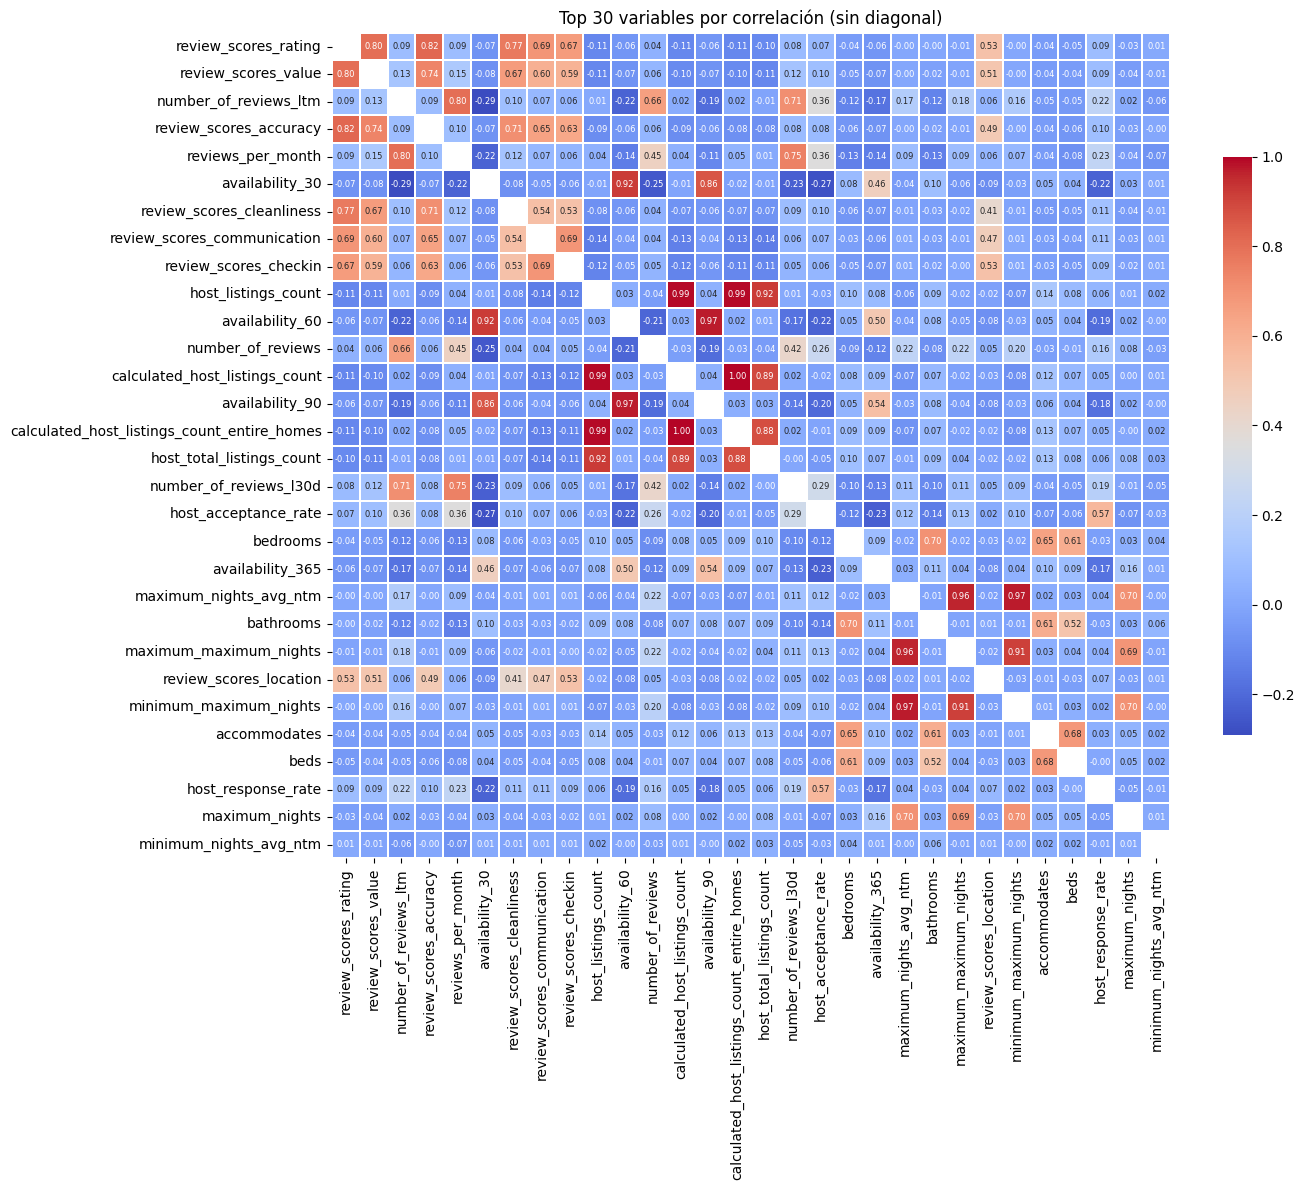

In [ ]:
#Seleccionamos el top 30 variables con mayor correlación promedio
corr = data.corr(numeric_only=True).abs()
mean_corr = corr.mean().sort_values(ascending=False)
top30 = mean_corr.index[:30]
subcorr = data[top30].corr().round(2)

#Creamos la máscara para ocultar la diagonal!
mask = np.eye(len(subcorr), dtype=bool)

plt.figure(figsize=(14,12))
sns.heatmap(
    subcorr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.3,
    annot_kws={"size":6},
    cbar_kws={"shrink":0.7}
)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.title("Top 30 variables por correlación (sin diagonal)")
plt.tight_layout()
plt.show()

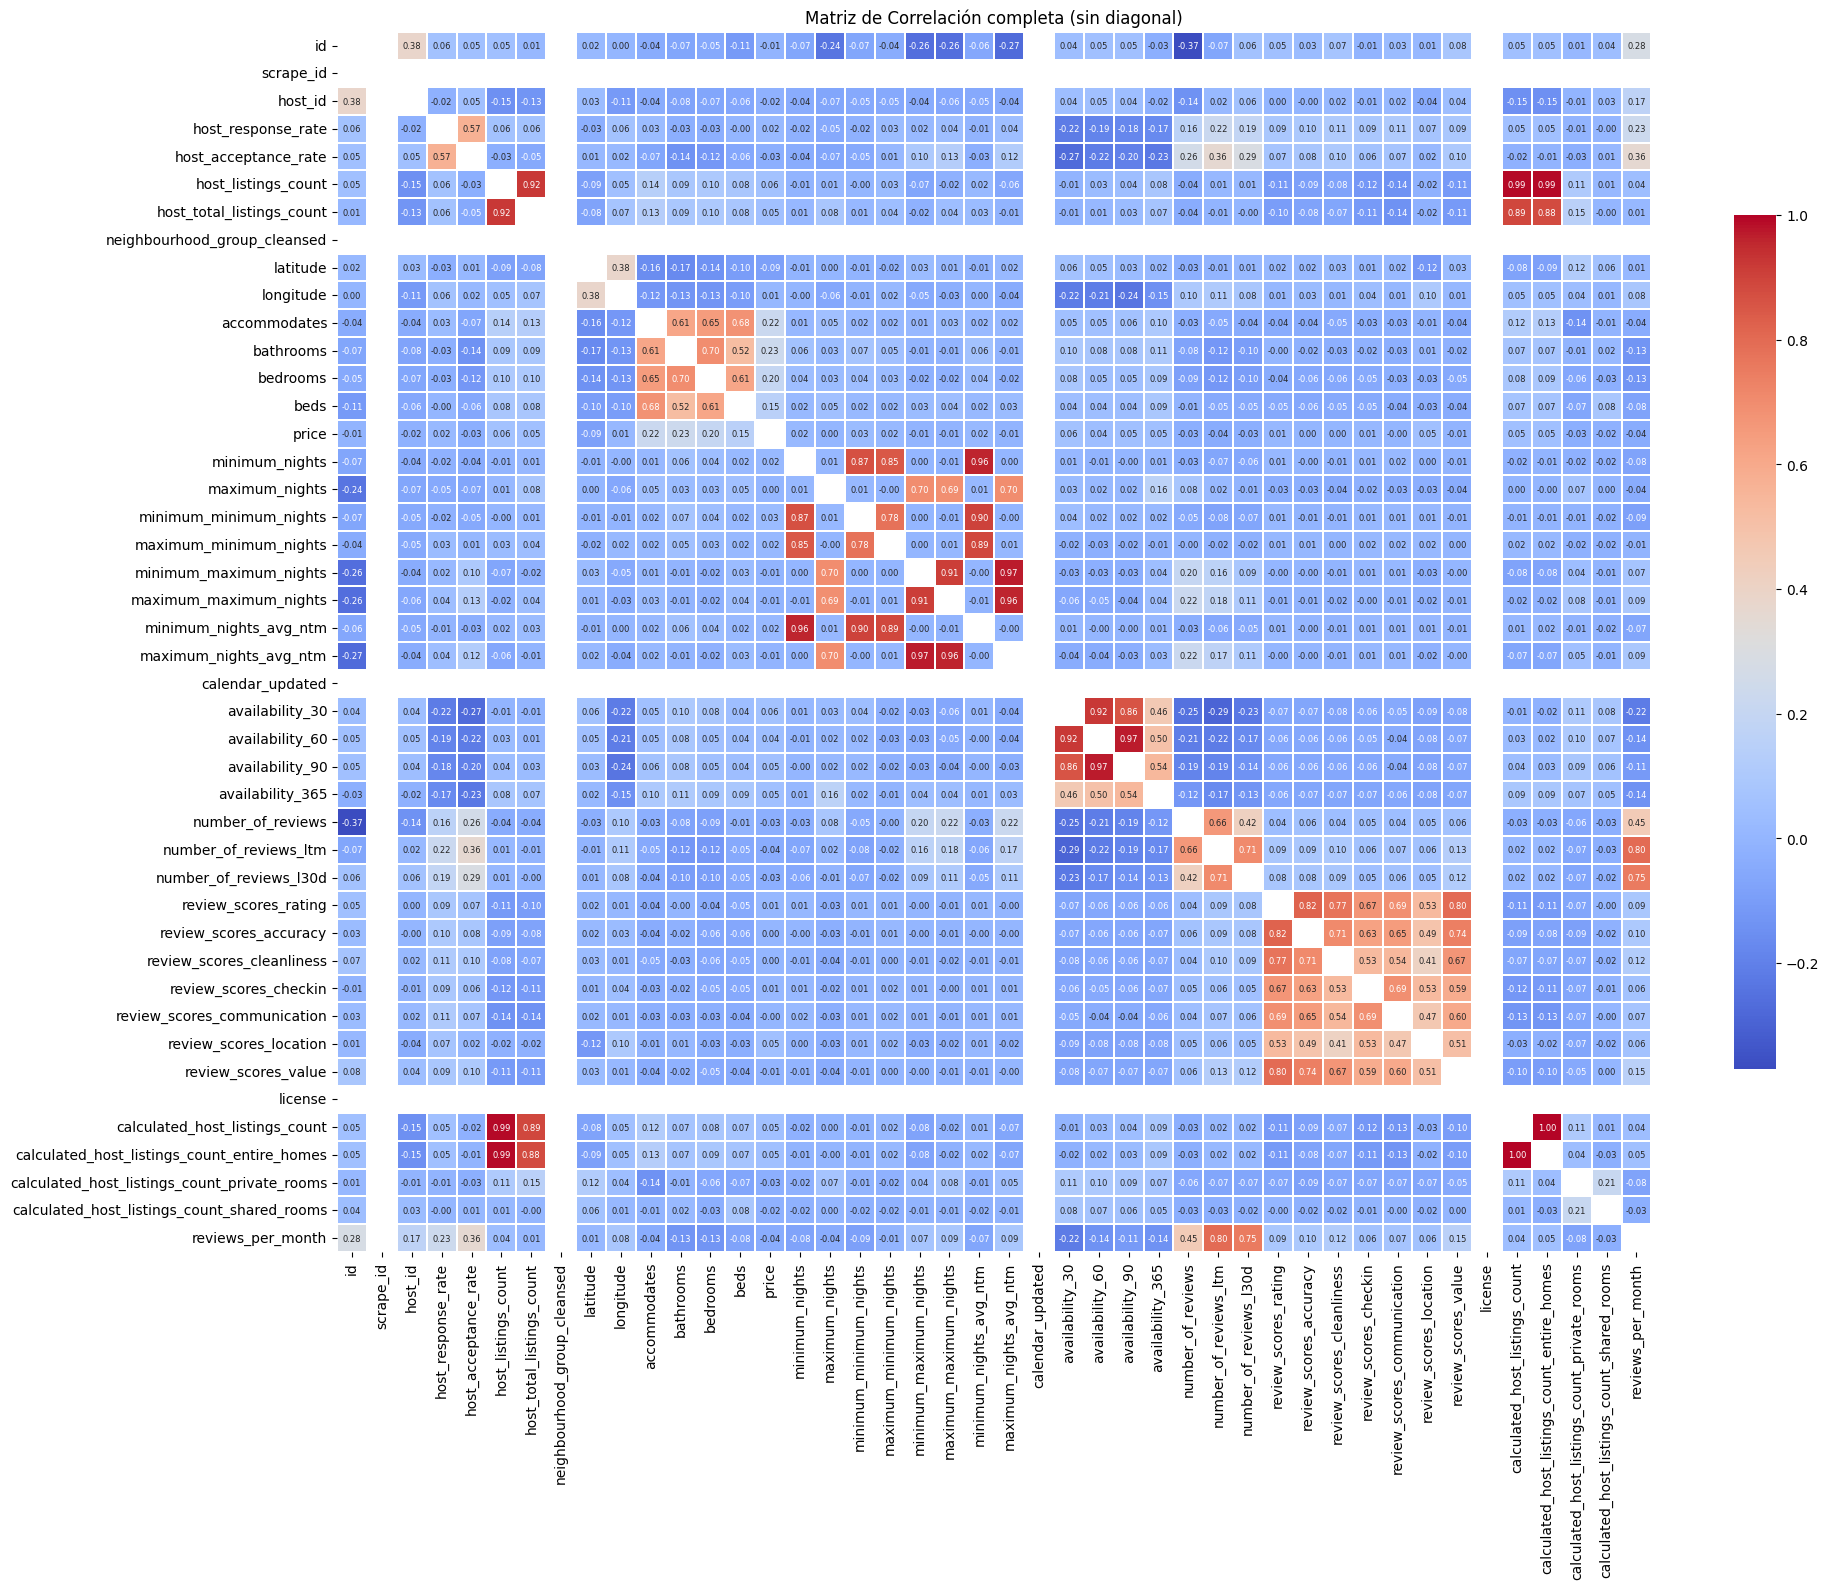

In [ ]:
#Calculamos la matriz de correlación de TODAS las variables numéricas
corr = data.corr(numeric_only=True).round(2)

#Creamos la máscara para ocultar la diagonal!
mask = np.eye(len(corr), dtype=bool)

plt.figure(figsize=(20,16))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.3,
    annot_kws={"size":6},
    cbar_kws={"shrink":0.7}
)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.title("Matriz de Correlación completa (sin diagonal)")
plt.tight_layout()
plt.show()

In [ ]:
#Correlaciones
corr_con_precio = data.corr(numeric_only=True)["price"].abs().sort_values(ascending=False).drop("price")

#Hacemos una tabla con tabulate
tabla_corr = list(zip(corr_con_precio.index, corr_con_precio.values))

print("Listado de variables numéricas y su correlación con price:")

print(tabulate(
    tabla_corr,
    headers=["Variable", "Correlación"],
    tablefmt="grid"
))


Listado de variables numéricas y su correlación con price:
+----------------------------------------------+---------------+
| Variable                                     |   Correlación |
+==============================================+===============+
| bathrooms                                    |   0.23279     |
+----------------------------------------------+---------------+
| accommodates                                 |   0.216004    |
+----------------------------------------------+---------------+
| bedrooms                                     |   0.204655    |
+----------------------------------------------+---------------+
| beds                                         |   0.14546     |
+----------------------------------------------+---------------+
| latitude                                     |   0.0870888   |
+----------------------------------------------+---------------+
| host_listings_count                          |   0.058212    |
+------------------------------

Observando las primeras 10 correlaciones con price, notamos que no hay tanta correlación con la variable price. Esperábamos resultados más claros, que nos indicaran casi un 1 de correlación... pero de todas formas es información interesante y relevante.

Se correlaciona **un poco** con:
- **bathrooms:** Número de baños en el anuncio
- **accommodates:** Número máximo de personas que el anuncio puede acomodar
- **bedrooms:** Número de dormitorios en el anuncio
- **beds:** Número de camas en el anuncio

<br>

Y se correlaciona pero **bastante menos** con:
- **latitude:** Latitud del anuncio (proyección WGS84)
- **host_listings_count:** Número de anuncios que tiene el anfitrión
- **availability_30:** Disponibilidad del anuncio en los próximos 30 días
- **host_total_listings_count:** Número total de anuncios que tiene el anfitrión
- **review_scores_location:** Puntuación de la ubicación en las reseñas
- **calculated_host_listings_count_entire_homes:** Número de anuncios de "Entire home/apt" que tiene el anfitrión en el scrape actual, en la ciudad/región geográfica

<br>

Es coherente que el precio esté relacionado a la cantidad de baños, camas y habitaciones, ya que cuantas más personas pueda hospedar, el alojamiento tendrá mas ambientes y metros cuadrados, lo cual hace más valiosa la propiedad.

Luego, observamos que la latitud está relacionada con el lugar geográfico donde se encuentra la propiedad, por lo que inferimos que el precio se ve afectado también por su ubicación. Depende de si es una zona muy transitada, de su ceracnía con el centro de la ciudad o atracciones/puntos visuales conocidos, si es de fácil acceso para transportarse, si es de alto prestigio o incluso más segura. Esto explicaría por qué la puntuación de la ubicación de las reseñas puede influir en el precio.

Analicemos la covarianza entre las variables:

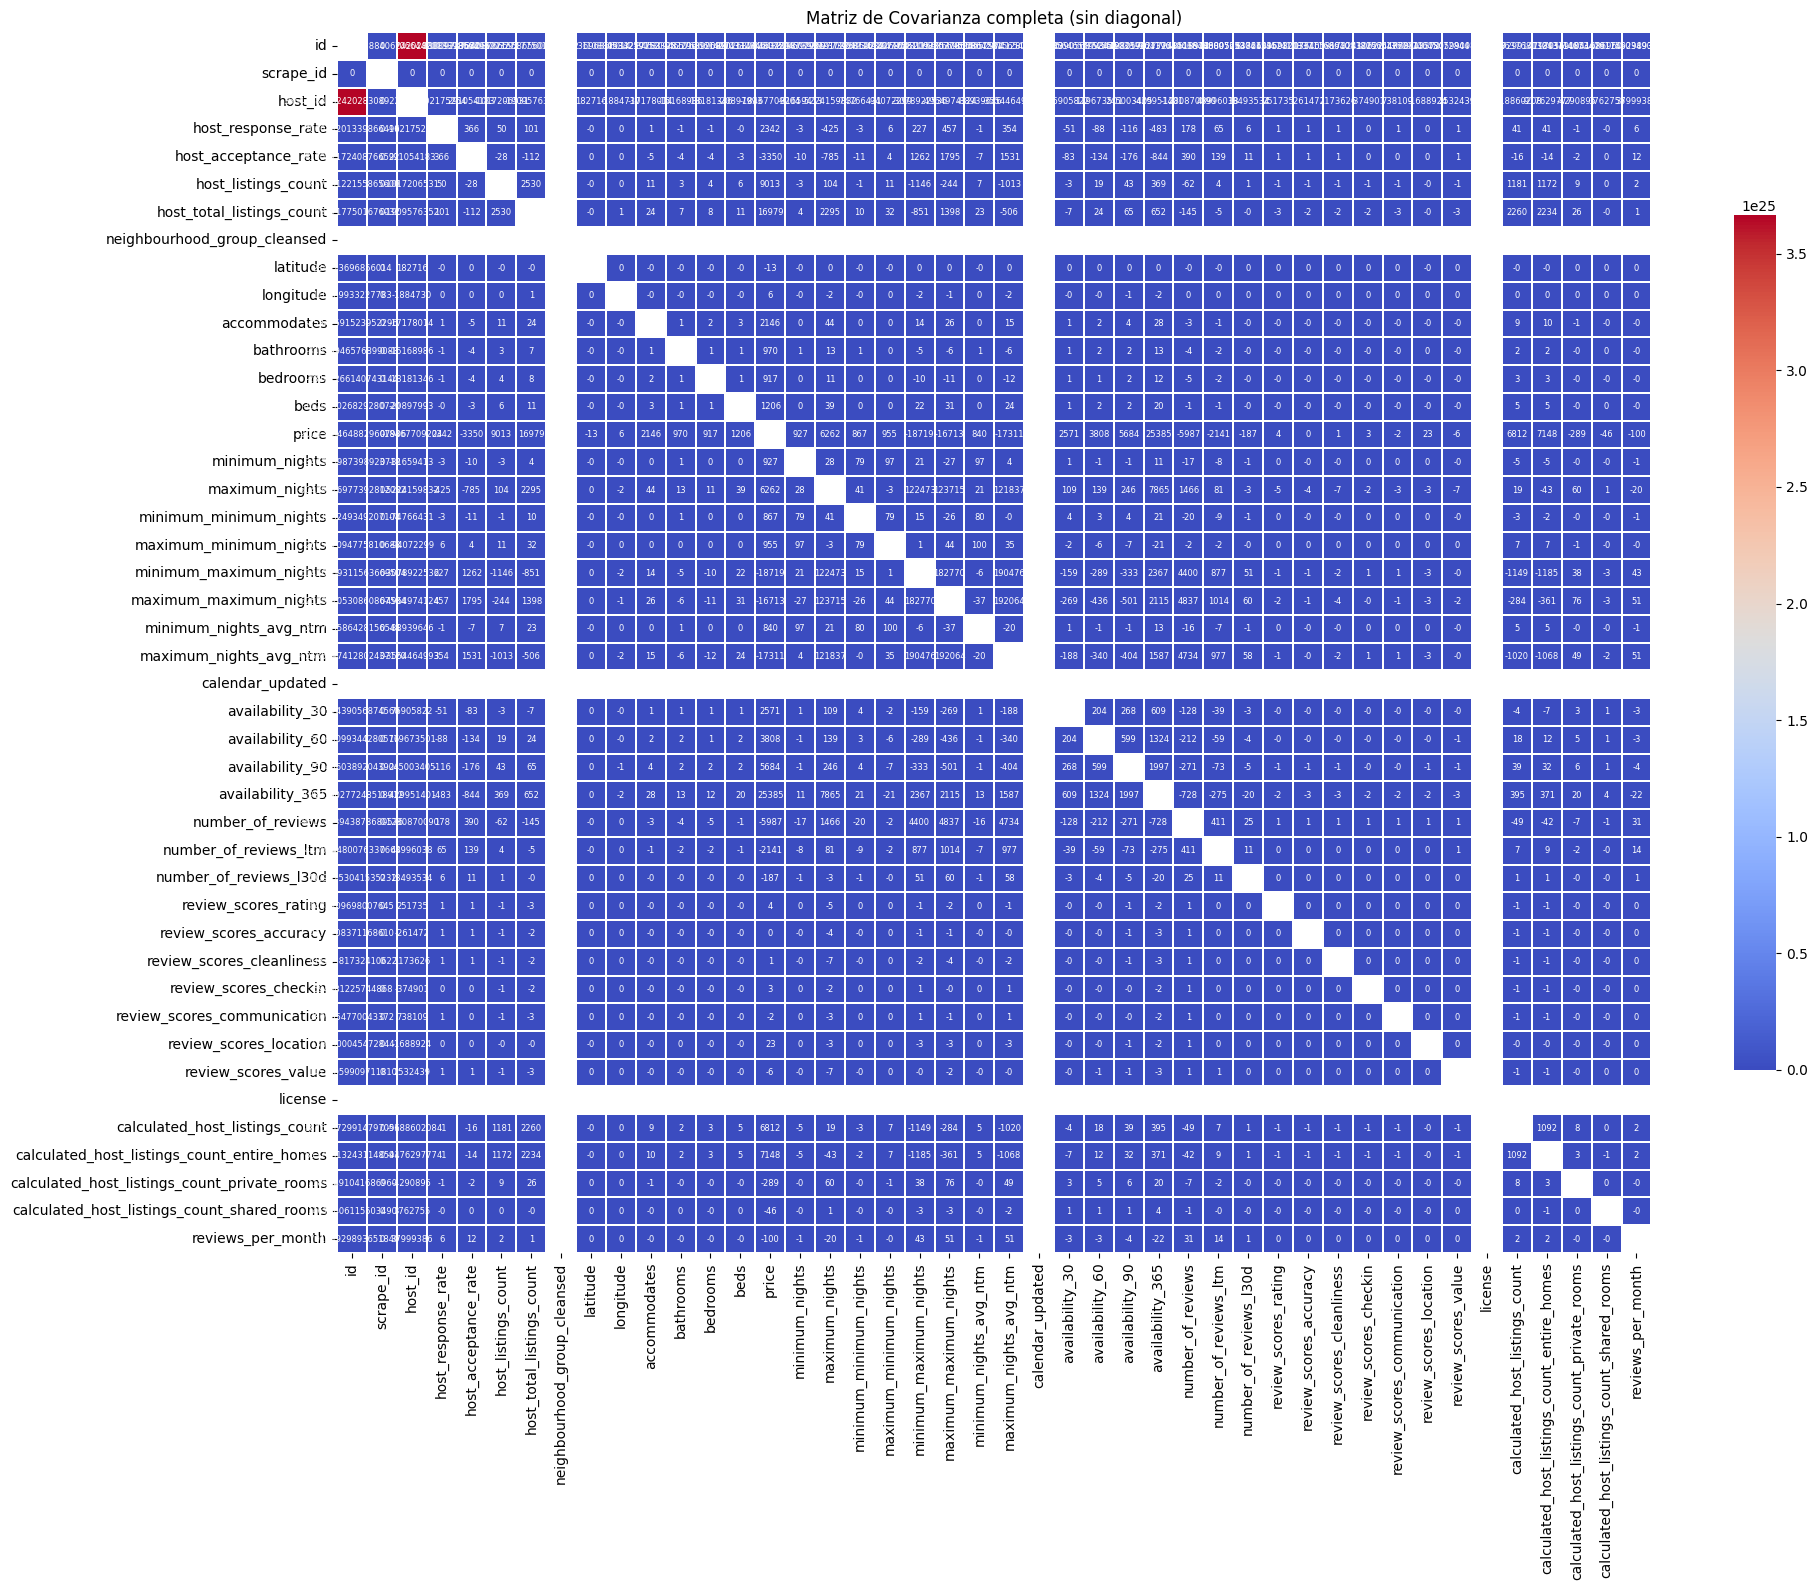

In [ ]:
#Calculamos la matriz de covarianza de TODAS las variables numéricas
cov = data.cov(numeric_only=True).round(0)

#Creamos la máscara para ocultar la diagonal!
mask = np.eye(len(cov), dtype=bool)

plt.figure(figsize=(20,16))
sns.heatmap(
    cov,
    mask=mask,
    annot=True,
    fmt=".0f",
    cmap="coolwarm",
    linewidths=0.3,
    annot_kws={"size":6},
    cbar_kws={"shrink":0.7}
)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.title("Matriz de Covarianza completa (sin diagonal)")
plt.tight_layout()
plt.show()

¿Cómo varía cada variable junto con la variable precio?

In [ ]:
#Covarianza
cov_con_precio = data.cov(numeric_only=True)["price"].abs().sort_values(ascending=False).drop("price")

#Hacemos una tabla con tabulate
tabla_cov = list(zip(cov_con_precio.index, cov_con_precio.values))

print("Listado de variables numéricas y su covarianza con price:")

print(tabulate(
    tabla_cov,
    headers=["Variable", "Covarianza"],
    tablefmt="grid"
))


Listado de variables numéricas y su covarianza con price:
+----------------------------------------------+-----------------+
| Variable                                     |      Covarianza |
+==============================================+=================+
| id                                           |     2.00333e+19 |
+----------------------------------------------+-----------------+
| host_id                                      |     1.84677e+10 |
+----------------------------------------------+-----------------+
| availability_365                             | 25385           |
+----------------------------------------------+-----------------+
| minimum_maximum_nights                       | 18718.8         |
+----------------------------------------------+-----------------+
| maximum_nights_avg_ntm                       | 17311.4         |
+----------------------------------------------+-----------------+
| host_total_listings_count                    | 16978.6         |
+---

Analicemos las 10 variables que tienen mayor covarianza con el precio:

Observamos que **id** y **host_id** tienen valores de covarianza enormes, pero eso no significa que sean relevantes para predecir el precio, pues ambos son identificadores únicos, por lo cual tiene sentido que siempre sea uno valor distinto del otro y por lo tanto varíen siempre.

<br>

Variables que presentan una covarianza positiva considerable con el precio, lo que sugiere que tienden a aumentar junto con él:

- **availability_365:** Disponibilidad del anuncio en los próximos 365 días
- **minimum_maximum_nights:** El valor más pequeño de máximo de noches de la reserva (viendo los 365 días futuros)
- **maximum_nights_avg_ntm:** Promedio de máximo de noches desde el calendario (viendo los 365 días futuros)
- **host_total_listings_count:** Número total de anuncios que tiene el anfitrión
- **maximum_maximum_nights:** El valor más grande de máximo de noches de la reserva (viendo los 365 días futuros)
- **host_listings_count:** Número de anuncios que tiene el anfitrión
- **calculated_host_listings_count_entire_homes:** Número de anuncios de "Entire home/apt" que tiene el anfitrión en el scrape actual, en la ciudad/región geográfica


<br>

Tiene sentido que el precio crezca con la disponibilidad. Esto dice que a mayor número de días disponibles, mayor tiende a ser el precio.

Por otro lado, minimum_maximum_nights, maximum_nights_avg_ntm, maximum_maximum_night son variables que establecen límites de noches que se puede reservar. A mayor duración posible de estadía, mayor va a ser el precio total (aunque el precio por noche quizás sea menor).


Es posible que anfitriones con más publicaciones tengan mayor experiencia o reputación, lo cual podría justificar precios más altos. El tener testimonios de otras personas/reseñas genera que el dueño de la publicación sea más confiable, por lo que se puede permitir precios más elevados. No es lo mismo alquilar una propiedad de una persona nueva en la plataforma a un precio muy barato que a una persona con más historial por más dinero.

También la cantidad de alojamientos tipo "casa/apartamento entero" publicados por el anfitrión influye, ya que este tipo de alojamiento suele tener un precio mayor que una habitación privada o compartida.


## Datos faltantes

In [ ]:
data_filtrada = data.copy()

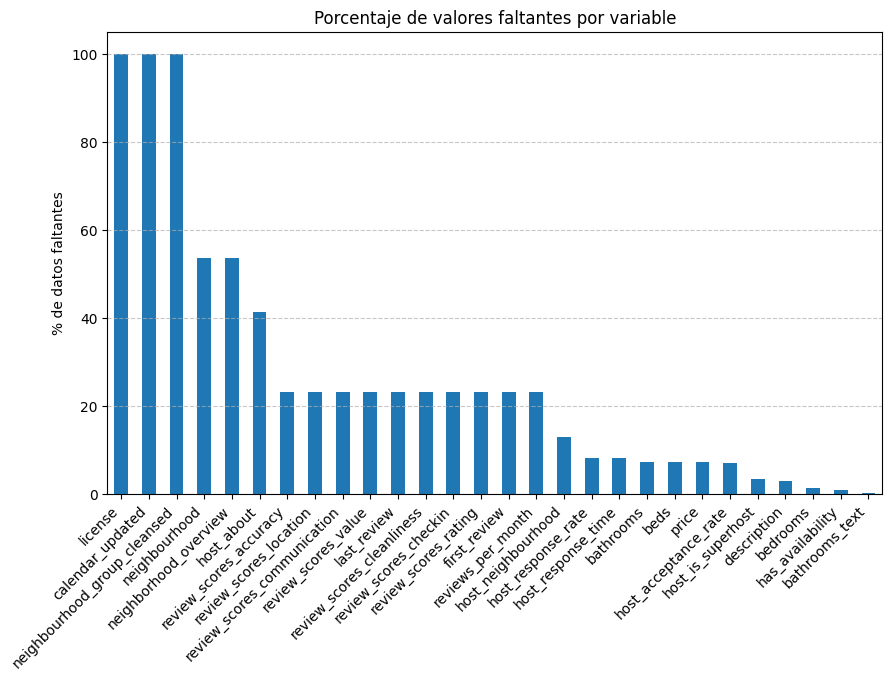

De 75 columnas, 28 (37.33%) tienen valores faltantes.


In [ ]:
#Porcentaje de valores faltantes por columna
faltantes_col = data_filtrada.isnull().mean().sort_values(ascending=False) * 100
faltantes_col = faltantes_col[faltantes_col > 0]  # solo las columnas con faltantes

#Gráfico
plt.figure(figsize=(10, 6))
faltantes_col.plot(kind='bar')
plt.title('Porcentaje de valores faltantes por variable')
plt.ylabel('% de datos faltantes')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.show()

#Porcentaje de datos faltantes por fila
data_filtrada.loc[:, 'porcentaje_nulos'] = data_filtrada.isnull().mean(axis=1) * 100


total_columnas = data_filtrada.shape[1] - 1  #restamos la columna 'porcentaje_nulos' agregada recién
columnas_con_nulos = faltantes_col.shape[0]
porcentaje = (columnas_con_nulos / total_columnas) * 100

print(f"De {total_columnas} columnas, {columnas_con_nulos} ({porcentaje:.2f}%) tienen valores faltantes.")


In [ ]:
print(data_filtrada['calendar_updated'].unique(), data_filtrada['license'].unique(), data_filtrada['neighbourhood_group_cleansed'].unique())

[nan] [nan] [nan]


Como solo tienen valores NaN, eliminamos las columnas ya que no aportan ningun tipo de información.

In [ ]:
data_filtrada = data_filtrada.drop(columns=["calendar_updated", "license", "neighbourhood_group_cleansed"])


In [ ]:
#Transformamos a datetime así se le puede imputar por moda
data_filtrada[["last_scraped", "host_since", "calendar_last_scraped", "first_review", "last_review"]] = data_filtrada[["last_scraped", "host_since", "calendar_last_scraped", "first_review", "last_review"]].apply(pd.to_datetime)

In [ ]:
#Actualizamos las listas de cuanti y cuali tras eliminar esas 3 col
variables_cuantitativas = [col for col in variables_cuantitativas if col in data_filtrada.columns]
variables_cualitativas = [col for col in variables_cualitativas if col in data_filtrada.columns]

#Imputamos valores faltantes en columnas cuantitativas con la mediana
for col in variables_cuantitativas:
    data_filtrada.loc[:, col] = data_filtrada[col].fillna(data_filtrada[col].median())

#Imputamos valores faltantes en columnas cualitativas con la moda
for col in variables_cualitativas:
    data_filtrada.loc[:, col] = data_filtrada[col].fillna(data_filtrada[col].mode()[0])

In [ ]:
print("Cantidad total de NaN en el dataset:", data_filtrada.isnull().sum().sum())
if(data_filtrada.isnull().sum().sum()) == 0:
  print("No hay datos faltantes!")

Cantidad total de NaN en el dataset: 0
No hay datos faltantes!


### Outliers

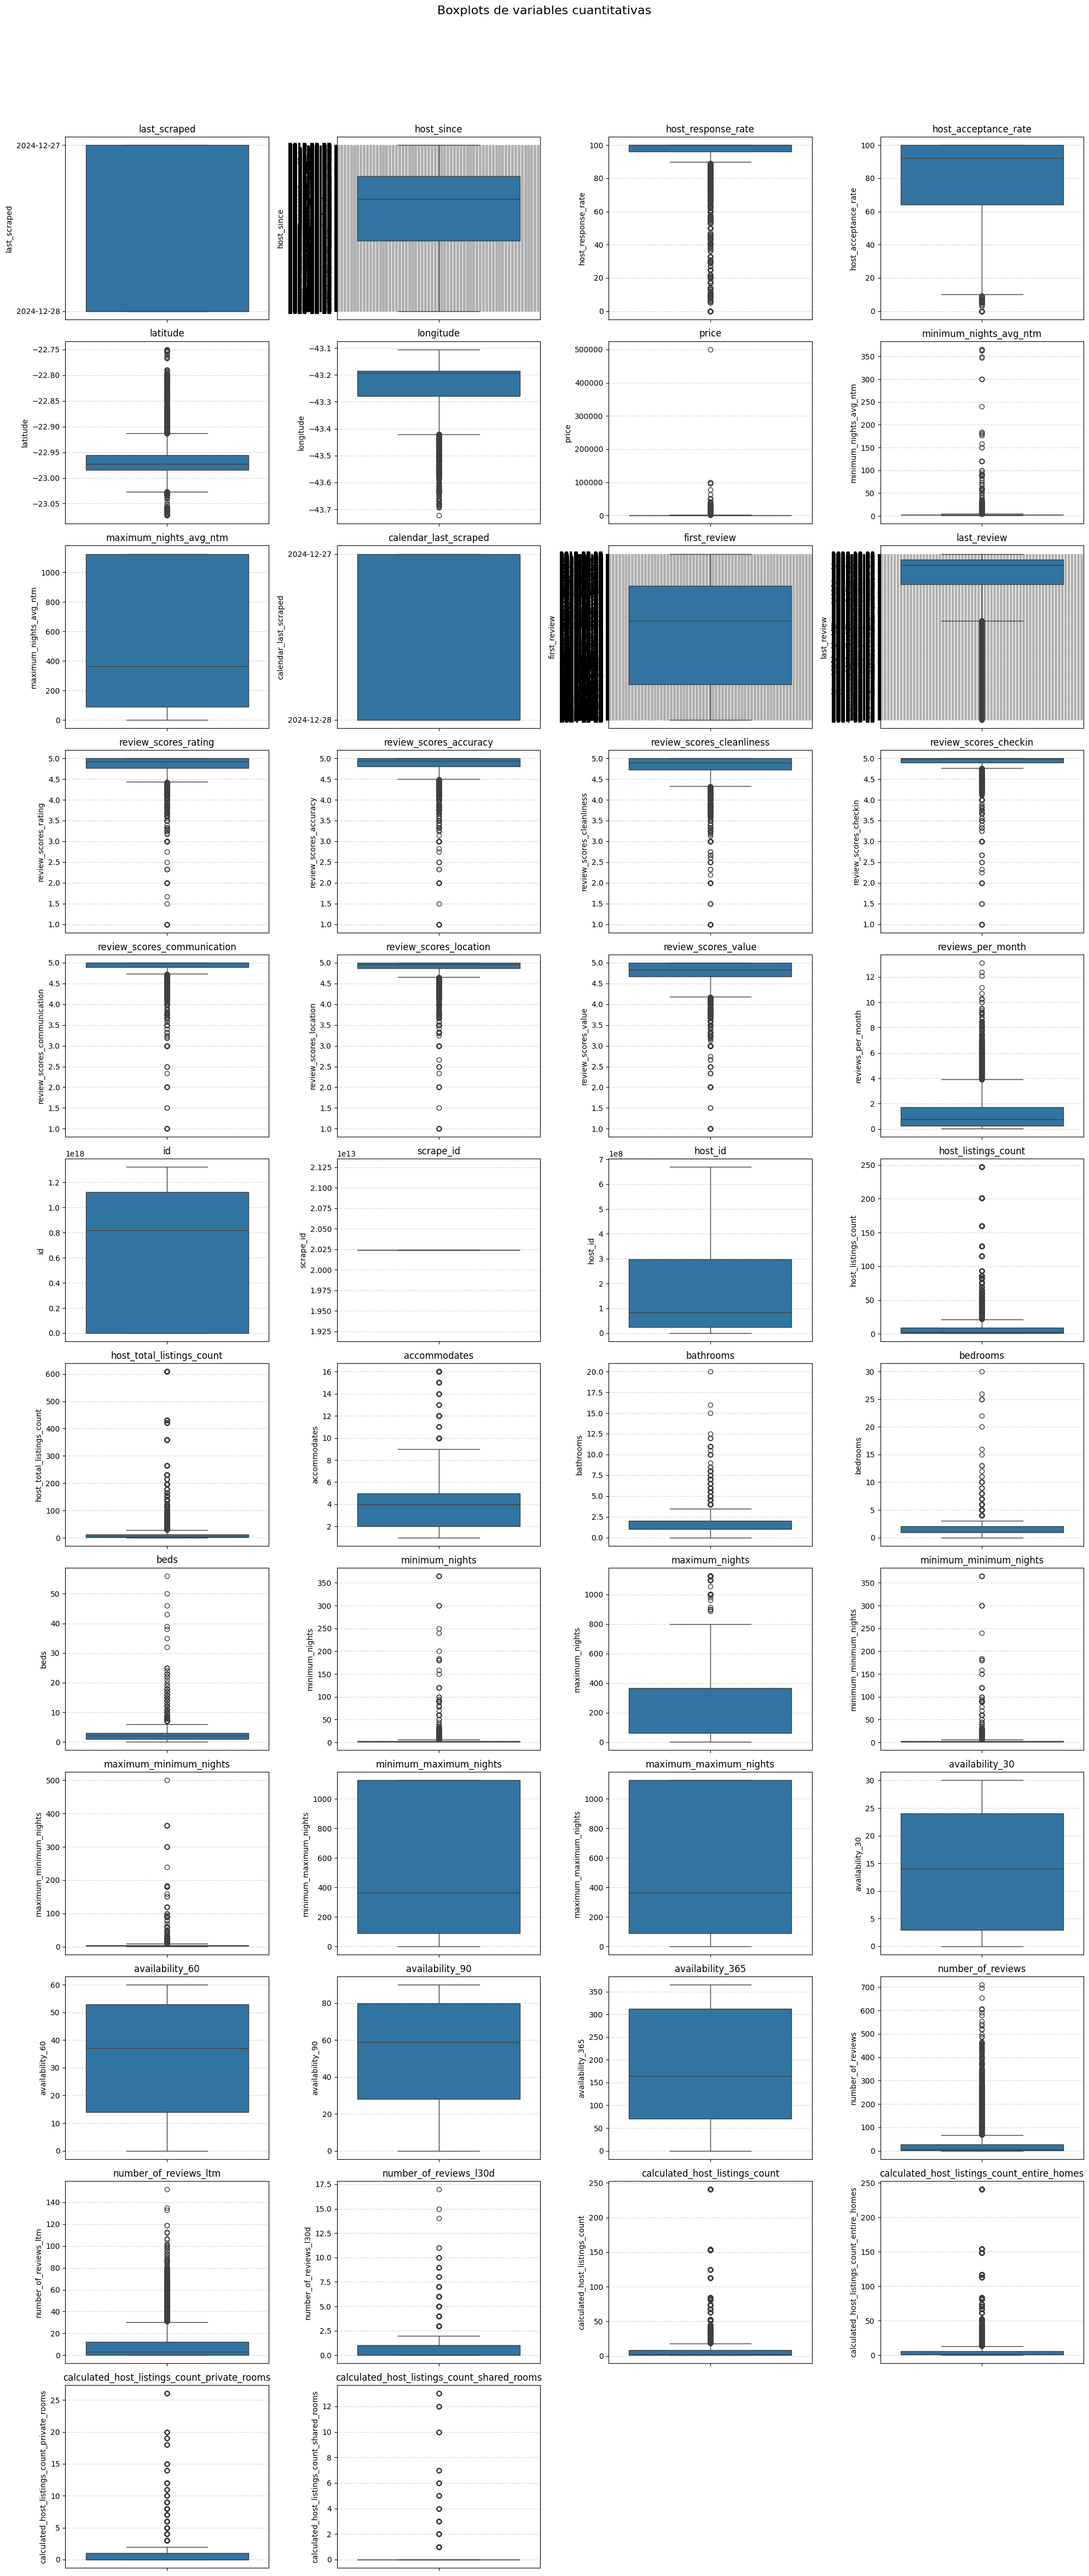

In [ ]:
#Boxplots individuales por variable cuantitativa

n = len(variables_cuantitativas)
cols = 4  #cantidad de columnas que querés en el grid
rows = -(-n // cols)  #división entera hacia arriba

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
axes = axes.flatten()

for i, col in enumerate(variables_cuantitativas ):
    sns.boxplot(data=data, y=col, ax=axes[i])
    axes[i].set_title(col)
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Boxplots de variables cuantitativas', fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()

####Con IQR

In [ ]:
print("Valores fuera del rango intercuartil (IQR):\n")

#Creamos el diccionario con los outliers univariados
outliers_univariados = {}

for col in variables_cuantitativas:
    Q1 = data_filtrada[col].quantile(0.25)
    Q3 = data_filtrada[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = data_filtrada[(data_filtrada[col] < Q1 - 1.5 * IQR) | (data_filtrada[col] > Q3 + 1.5 * IQR)]
    outliers_univariados[col] = outliers.shape[0]

#Lo pasamos a DataFrame
tabla_outliers = pd.DataFrame.from_dict(outliers_univariados, orient='index', columns=['Cantidad de outliers'])
tabla_outliers = tabla_outliers.sort_values(by='Cantidad de outliers', ascending=False)

display(tabla_outliers)

# Imprimimos la sumatoria de todos los outliers
total_outliers = sum(outliers_univariados.values())
print(f"Total de outliers en todas las columnas: {total_outliers}")

Valores fuera del rango intercuartil (IQR):



,Cantidad de outliers
host_response_rate,4792
maximum_nights,4692
last_review,4688
calculated_host_listings_count_entire_homes,4157
host_listings_count,3901
host_total_listings_count,3898
calculated_host_listings_count,3709
first_review,3145
minimum_nights_avg_ntm,3105
review_scores_checkin,2869


Total de outliers en todas las columnas: 78192


Hay varias que parecieran no tener outliers: minimum_maximum_nights, maximum_maximum_nights, availability_30, availability_60, availability_90, availability_365, host_since, host_id, scrape_id, id, calendar_last_scraped, maximum_nights_avg_ntm, last_scraped

####Usamos Z-Score

In [ ]:
from scipy.stats import zscore

In [ ]:
data_filtrada.shape

(24442, 73)

In [ ]:
#Seleccionamos todas las columnas que no son de tipo 'datetime' porque sino Z-score rompe
variables_cuantitativas = data_filtrada.select_dtypes(include=['number']).columns


z_scores = data_filtrada[variables_cuantitativas].apply(zscore)

#Definimos el umbral de Z-Score (3)
umbral = 3
outliers_zscore = {}

#Contamos los outliers por cada columna
for col in variables_cuantitativas:
    outliers_zscore[col] = (np.abs(z_scores[col]) > umbral).sum()

#Mostramos los outliers por columna
tabla_outliers_z = pd.DataFrame.from_dict(outliers_zscore, orient='index', columns=['Cantidad de outliers (Z-Score)'])
tabla_outliers_z = tabla_outliers_z.sort_values(by='Cantidad de outliers (Z-Score)', ascending=False)

display(tabla_outliers_z)

total_outliers = sum(outliers_univariados.values())
print(f"Total de outliers en todas las columnas: {total_outliers}")

,Cantidad de outliers (Z-Score)
host_response_rate,1085
calculated_host_listings_count_entire_homes,786
calculated_host_listings_count,786
host_listings_count,673
calculated_host_listings_count_private_rooms,637
host_total_listings_count,612
number_of_reviews,545
number_of_reviews_ltm,513
number_of_reviews_l30d,500
reviews_per_month,490


Total de outliers en todas las columnas: 78192


In [ ]:
#Iteramos sobre cada columna y filtramos los outliers
for col in variables_cuantitativas:
    z_col = z_scores[col]

    #Vemos las filas que tienen Z-Score fuera del umbral (3)
    mascara_outliers = np.abs(z_col) > umbral

    data_filtrada = data_filtrada.loc[~mascara_outliers]

data_filtrada.shape

(18342, 73)

##b) Entrenamiento y Predicción

Para entrenar todos los modelos, vamos a eliminar columnas que consideramos irrelevantes ya que no aportan información útil para el modelado del precio de un alojamiento. Entre ellas tenemos:

**Identificadores y URLs** (id, scrape_id, listing_url, host_id, host_url, picture_url, host_thumbnail_url, host_picture_url): son únicos para cada fila o simplemente enlaces, y no representan patrones que puedan aprender los modelos.

**Textos largos o redundantes** (name, description, neighborhood_overview, host_about, host_name, host_location, host_neighbourhood, host_verifications, bathrooms_text)

**Variable auxiliar** (porcentaje_nulos): fue útil para el análisis exploratorio pero no corresponde incluirla como feature del modelo.

Pero también transformamos los datos de algunas variables que creemos que si pueden influir en el precio de un alojamiento, entre ellas podemos mencionar:

**Las columnas con fechas** (last_scraped, calendar_last_scraped, first_review, last_review, host_since) fueron convertidas en antigüedad en días. Realizamos esto pues el valor absoluto de una fecha no aporta información al modelo pero en cambio, la antigüedad (por ejemplo, cuántos días pasaron desde la última reseña o desde que el host se unió) puede ser informativa del estado actual del alojamiento o del comportamiento del anfitrión.

La columna **amenities**, que contiene una lista de servicios como texto, fue transformada a una variable numérica representando la cantidad total de amenities disponibles. Esta simplificación permite evitar una expansión excesiva de columnas si se hiciera one-hot encoding y también aportar un valor que se correlaciona intuitivamente con el precio (más servicios, mayor precio esperado).

In [ ]:
print(data_filtrada.dtypes.value_counts())

object            26
int64             21
float64           21
datetime64[ns]     5
Name: count, dtype: int64


In [ ]:
def preparar_dataset(data_filtrada):

    #Eliminamos columnas irrelevantes
    columnas_a_eliminar = [
        'id', 'scrape_id', 'listing_url', 'host_id', 'host_url',
        'picture_url', 'host_thumbnail_url', 'host_picture_url',
        'name', 'host_name',
        'host_location', 'host_neighbourhood', 'host_verifications',
        'bathrooms_text', 'porcentaje_nulos', 'source', 'host_response_time', 'neighbourhood', 'property_type', 'room_type'
    ]
    data = data_filtrada.drop(columns=columnas_a_eliminar, errors='ignore')

    #Transformamos fechas a antigüedad en días
    columnas_fecha = [
        'last_scraped', 'calendar_last_scraped',
        'first_review', 'last_review', 'host_since'
    ]

    for col in columnas_fecha:
        if col in data.columns:
            #Reemplazar por la antigüedad en días
            data[col + '_antiguedad_dias'] = (data[col].max() - data[col]).dt.days
            data.drop(columns=col, inplace=True)

    #Transformamos 'amenities' en cantidad de amenities
    if 'amenities' in data.columns:
        data['amenities_count'] = data['amenities'].apply(lambda x: len(eval(x)) if pd.notnull(x) else 0)
        data.drop(columns='amenities', inplace=True)

    #Nueva columna: largo de 'host_about'
    if 'host_about' in data_filtrada.columns:
        data['host_about_length'] = data_filtrada['host_about'].apply(lambda x: len(str(x)) if pd.notnull(x) else 0)
        data.drop(columns='host_about', inplace=True)

        #Nueva columna: largo de 'neighborhood_overview'
    if 'neighborhood_overview' in data_filtrada.columns:
        data['neighborhood_overview_length'] = data_filtrada['neighborhood_overview'].apply(lambda x: len(str(x)) if pd.notnull(x) else 0)
        data.drop(columns='neighborhood_overview', inplace=True)

         #Nueva columna: largo de 'description'
    if 'description' in data_filtrada.columns:
        data['description_length'] = data_filtrada['description'].apply(lambda x: len(str(x)) if pd.notnull(x) else 0)
        data.drop(columns='description', inplace=True)

    return data


In [ ]:
df = data_filtrada.copy()
df = preparar_dataset(df)

In [ ]:
df.shape
df.columns.tolist()

['host_response_rate',
 'host_acceptance_rate',
 'host_is_superhost',
 'host_listings_count',
 'host_total_listings_count',
 'host_has_profile_pic',
 'host_identity_verified',
 'neighbourhood_cleansed',
 'latitude',
 'longitude',
 'accommodates',
 'bathrooms',
 'bedrooms',
 'beds',
 'price',
 'minimum_nights',
 'maximum_nights',
 'minimum_minimum_nights',
 'maximum_minimum_nights',
 'minimum_maximum_nights',
 'maximum_maximum_nights',
 'minimum_nights_avg_ntm',
 'maximum_nights_avg_ntm',
 'has_availability',
 'availability_30',
 'availability_60',
 'availability_90',
 'availability_365',
 'number_of_reviews',
 'number_of_reviews_ltm',
 'number_of_reviews_l30d',
 'review_scores_rating',
 'review_scores_accuracy',
 'review_scores_cleanliness',
 'review_scores_checkin',
 'review_scores_communication',
 'review_scores_location',
 'review_scores_value',
 'instant_bookable',
 'calculated_host_listings_count',
 'calculated_host_listings_count_entire_homes',
 'calculated_host_listings_count_pr

In [ ]:
print(df.dtypes.value_counts())

int64      27
float64    20
object      6
Name: count, dtype: int64


Al querer utilizar variables categóricas como variables predictoras, necesitamos realizar transformaciones sobre las mismas. Por lo tanto, realizaremos el método One Hot Encoding sobre las cualitativas **has_availability, instant_bookable, host_has_profile_pic
, host_identity_verified, host_is_superhost, neighbourhood_cleansed**

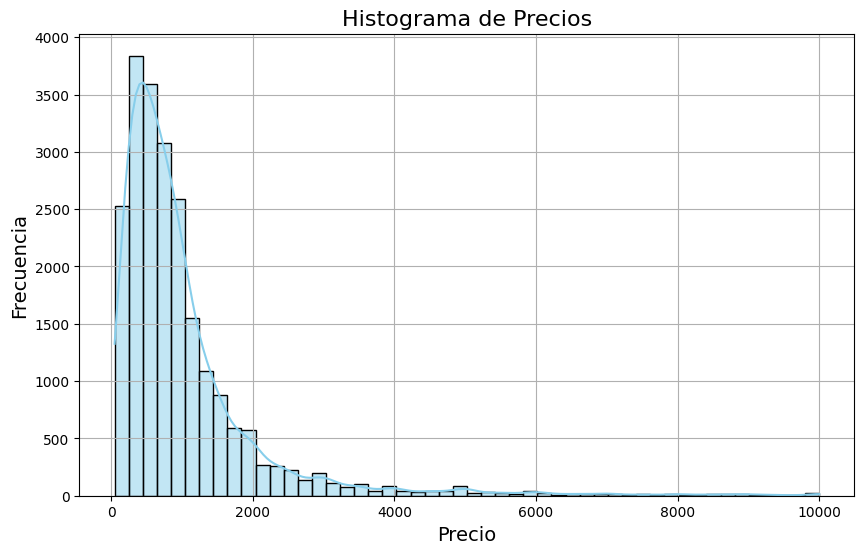

In [ ]:
#Primero recortamos outliers (opcional pero recomendado)
price_limit = data['price'].quantile(0.99)  # Recortar al percentil 99
filtered_data = data[data['price'] <= price_limit]

plt.figure(figsize=(10, 6))
sns.histplot(filtered_data['price'], bins=50, kde=True, color='skyblue')
plt.title('Histograma de Precios', fontsize=16)
plt.xlabel('Precio', fontsize=14)
plt.ylabel('Frecuencia', fontsize=14)
plt.grid(True)
plt.show()


In [ ]:
#Features
print(data.columns.tolist())

['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated', 'has_availability', 'availability_30', 'availability_60', 'availability_90', 'availabil

In [ ]:
print(variables_cuantitativas)

Index(['id', 'scrape_id', 'host_id', 'host_response_rate',
       'host_acceptance_rate', 'host_listings_count',
       'host_total_listings_count', 'latitude', 'longitude', 'accommodates',
       'bathrooms', 'bedrooms', 'beds', 'price', 'minimum_nights',
       'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights',
       'minimum_maximum_nights', 'maximum_maximum_nights',
       'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'availability_30',
       'availability_60', 'availability_90', 'availability_365',
       'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d',
       'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value', 'calculated_host_listings_count',
       'calculated_host_listings_count_entire_homes',
       'calculated_host_listings_count_private_rooms',
       'calculated_host_listin

####Funciones para el análisis de los resultados

In [ ]:
#Función para imprimir métricas
def print_metricas(y_true, y_pred, dataset_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"--- {dataset_name} ---")
    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²: {r2:.4f}")
    print()

In [ ]:
def categorizar_price(price):
    if price < 100:
        return 'bajo'
    elif price < 300:
        return 'medio'
    else:
        return 'alto'

####Imports necesarios

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, make_scorer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split

##Regresión Lineal Múltiple

In [ ]:
#Dividimos los datos
#X son las características (sin la columna 'price')

data_filtrada_con_dummies = df.copy()

data_filtrada_con_dummies = pd.get_dummies(data_filtrada_con_dummies, columns=["has_availability", "instant_bookable", "host_has_profile_pic", "host_identity_verified", "host_is_superhost","neighbourhood_cleansed"], drop_first=True)

x2 = data_filtrada_con_dummies.drop('price', axis=1)  #Las columnas que se usarán como entrada para el modelo
y2 = data_filtrada_con_dummies['price']  #Esta es la que queremos predecir (la objetivo)

data_filtrada_con_dummies= data_filtrada_con_dummies.map(lambda x: int(x) if isinstance(x, bool) else x)

#Dividir en 80% entrenamiento y 20% test
x2_train, x2_test, y2_train, y2_test = train_test_split(x2,
                                                    y2,
                                                    test_size=0.2, #proporcion 80/20
                                                    random_state=42) #random_state para que siempre de los mismos resultados al correr



In [ ]:
data_filtrada_con_dummies.shape

(18342, 145)

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
#Normalizar las variables numéricas
normalizar = StandardScaler()
x2_train_escalado = normalizar.fit_transform(x2_train)
x2_test_escalado = normalizar.transform(x2_test)

#Creamos el regresor lineal
modelo_lineal_multiple = LinearRegression()

#Entrenamos el modelo
modelo_lineal_multiple.fit(x2_train_escalado, y2_train)

# Predecir sobre el conjunto de test
y2_pred = modelo_lineal_multiple.predict(x2_test_escalado)

# Evaluar el modelo
mse = mean_squared_error(y2_test, y2_pred)
r2 = r2_score(y2_test, y2_pred)

#Obtenemos los coeficientes y el intercepto y las métricas
print("Coeficientes:", modelo_lineal_multiple.coef_)
print("\n")
print("Intercepto:", modelo_lineal_multiple.intercept_)
print("\n")
print("Error cuadrático medio (MSE):", mse)
print("Coeficiente de determinación (R²):", r2)

Coeficientes: [ 4.54867400e+00  3.20526557e+01  9.35206571e+01 -4.42141792e+00
 -3.05111444e+02  1.26084832e+02  1.57847635e+02  2.20209868e+02
  1.25032194e+02  5.32173763e+01  5.43658610e+01 -1.51151155e+01
  3.96608967e+01  2.39244681e+01 -1.59110796e+01  1.06720521e+01
 -1.05229206e+02 -7.26542123e+00  2.64910979e+02 -3.92954907e+02
  2.66830845e+02  4.14862613e+01 -5.70263420e+00 -4.37851801e-01
 -1.59925168e+01 -8.91355226e+00  2.53064991e+01  3.64725387e+01
  3.28962165e-01  1.53394519e+01  1.07154883e+01 -1.64327080e+01
 -1.51656344e+03  1.61099604e+03  6.89852486e+01  1.22261808e+01
 -3.48913248e+00 -4.39719753e+01 -4.39719753e+01 -1.55241235e+01
  3.29730953e+01 -6.29548439e+00  2.73115474e+01 -1.45166756e+01
  1.96154047e+01 -1.89626628e+01  1.12890430e+00  3.21224094e+01
  8.56584288e+00  4.98769187e+00  2.75617563e+01 -3.67091103e+00
 -1.36850768e+01 -2.85518353e+01 -4.03588274e-12 -2.40854947e+02
 -7.16985177e+00 -3.95558785e+00  5.82291903e+00 -1.23808995e+02
 -1.2790028

In [ ]:
#Predicciones en el conjunto de entrenamiento
y2_train_pred = modelo_lineal_multiple.predict(x2_train_escalado)

#Predicciones en el conjunto de test
y2_test_pred = modelo_lineal_multiple.predict(x2_test_escalado)

#Mostramos los resultados
print_metricas(y2_train, y2_train_pred, "Train")
print_metricas(y2_test, y2_test_pred, "Test")

--- Train ---
MAE: 468.57
MSE: 738429.01
RMSE: 859.32
R²: 0.3710

--- Test ---
MAE: 448.59
MSE: 663321.02
RMSE: 814.45
R²: 0.3467



In [ ]:
#Usamos las columnas del set de entrenamiento con dummies
columnas = x2_train.columns.tolist()

#Asociamos coeficientes con nombres de columnas
coef_df = pd.DataFrame({
    'feature': columnas,
    'coeficiente': modelo_lineal_multiple.coef_
})

#Ordenamos por valor absoluto del coeficiente
coef_df['importancia'] = np.abs(coef_df['coeficiente'])
coef_df = coef_df.sort_values(by='importancia', ascending=False)

print(coef_df[['feature', 'coeficiente']].head(10))  #Top 10 más influyentes

#Positivos: tiende a aumentar el precio
#Negativos: al revés

                                             feature  coeficiente
33       calculated_host_listings_count_entire_homes        1,611
32                    calculated_host_listings_count       -1,517
19                                   availability_60         -393
73                 neighbourhood_cleansed_Copacabana         -321
4                                           latitude         -305
20                                   availability_90          267
18                                   availability_30          265
55            neighbourhood_cleansed_Barra da Tijuca         -241
119  neighbourhood_cleansed_Recreio dos Bandeirantes         -237
7                                          bathrooms          220


##XGBoost

In [ ]:
!pip install xgboost
import xgboost as xgb
from xgboost import XGBRegressor

In [ ]:
#Dividimos los datos
#X son las características (sin la columna 'Price')


data_filtrada_con_dummies = df.copy()

data_filtrada_con_dummies = pd.get_dummies(data_filtrada_con_dummies, columns=["has_availability", "instant_bookable", "host_has_profile_pic", "host_identity_verified", "host_is_superhost", "neighbourhood_cleansed"], drop_first=True)

x3 = data_filtrada_con_dummies.drop('price', axis=1)  #Las columnas que se usarán como entrada para el modelo
y3 = data_filtrada_con_dummies['price']  #Esta es la que queremos predecir (la objetivo)

data_filtrada_con_dummies= data_filtrada_con_dummies.map(lambda x: int(x) if isinstance(x, bool) else x)

#Dividir en 80% entrenamiento y 20% test
x3_train, x3_test, y3_train, y3_test = train_test_split(x3,
                                                    y3,
                                                    test_size=0.2, #proporcion 80/20
                                                    random_state=42) #random_state para que siempre de los mismos resultados al correr

In [ ]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_scorer = make_scorer(rmse, greater_is_better=False)

#Definimos los hiperparámetros
param_distributions = {
    'n_estimators': [700, 800, 900],
    'max_depth': [5],
    'learning_rate': [0.03, 0.04],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8],
    'gamma': [1, 1.5],
    'lambda': [2, 3],
    'alpha': [1.0, 1.5]
}


#Configuramos la cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

xgb_model = xgb.XGBRegressor(random_state=42)

#RandomizedSearch
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_distributions,
    n_iter=10,  #número de combinaciones que va a probar
    scoring=rmse_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(x3_train, y3_train)
print("Mejores parámetros encontrados:", random_search.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Mejores parámetros encontrados: {'subsample': 0.8, 'n_estimators': 900, 'max_depth': 5, 'learning_rate': 0.03, 'lambda': 3, 'gamma': 1, 'colsample_bytree': 0.7, 'alpha': 1.5}


In [ ]:
#Modelo con mejores parámetros
best_model = random_search.best_estimator_

#Evaluación en test
y3_pred = best_model.predict(x3_test)
y3_train_pred = best_model.predict(x3_train)

print_metricas(y3_train, y3_train_pred, "Train")
print_metricas(y3_test, y3_pred, "Test")

--- Train ---
MAE: 264.05
MSE: 197073.38
RMSE: 443.93
R²: 0.8321

--- Test ---
MAE: 350.74
MSE: 441778.32
RMSE: 664.66
R²: 0.5649



Text(50.722222222222214, 0.5, 'True')

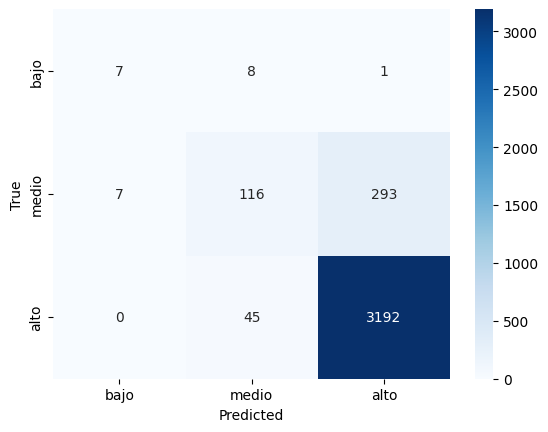

In [ ]:
y_true_cat = y3_test.apply(categorizar_price)
y_pred_cat = pd.Series(y3_pred).apply(categorizar_price)

cm = confusion_matrix(y_true_cat, y_pred_cat, labels=['bajo', 'medio', 'alto'])
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g', xticklabels=['bajo', 'medio', 'alto'], yticklabels=['bajo', 'medio', 'alto'])
plt.xlabel('Predicted')
plt.ylabel('True')


##K-NN - Regresión (K-Nearest Neighbors)

Para trabajar con este modelo, primero vamos a verificar que no haya valores NaN ya que KNN no los puede manejar, luego vamos a convertir todas las variables categóricas a numéricas (realizando one-hot encoding). Y por último, como KNN se basa en distancias (como la Euclídea), vamos a normalizar las variables cuantitativas.

In [ ]:
data_filtrada_knn = df.copy()

In [ ]:
data_filtrada_knn.shape

(18342, 53)

In [ ]:
print(data_filtrada_knn.dtypes.value_counts())

int64      27
float64    20
object      6
Name: count, dtype: int64


In [ ]:
object_columns = data_filtrada_knn.select_dtypes(include='object').columns
print(object_columns)

Index(['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified',
       'neighbourhood_cleansed', 'has_availability', 'instant_bookable'],
      dtype='object')


In [ ]:
data_filtrada_knn = data_filtrada_knn.drop('neighbourhood_cleansed', axis=1)

#One-Hot Encoding solo para las columnas seleccionadas
data_filtrada_knn = pd.get_dummies(
    data_filtrada_knn,
    columns=['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified', 'has_availability', 'instant_bookable'],
    drop_first=True
)

#Verificamos que ahora solo queden columnas numéricas y las dummies
print(data_filtrada_knn.dtypes.value_counts())

int64      27
float64    20
bool        5
Name: count, dtype: int64


In [ ]:
#Convertimos todas las columnas de tipo booleano a 1 y 0
data_filtrada_knn = data_filtrada_knn.astype(int)

#Verificamos que ahora solo queden columnas numéricas
print(data_filtrada_knn.dtypes.value_counts())


int64    52
Name: count, dtype: int64


In [ ]:
#Calculamos la matriz de correlación entre todas las variables numéricas
correlacion_matrix = data_filtrada_knn.corr(numeric_only=True).abs()

#Creamos una lista con las correlaciones más altas, excluyendo las correlaciones de la variable consigo misma (valores en la diagonal) y las NaN
correlacion_lista = []

#Iteramos sobre la matriz de correlación para obtener las correlaciones entre todas las variables
for col in correlacion_matrix.columns:
    for row in correlacion_matrix.index:
        if row != col:  # Excluir la correlación de la variable consigo misma
            correlacion_valor = correlacion_matrix.loc[row, col]
            if pd.notna(correlacion_valor):  # Solo agregar si la correlación no es NaN
                correlacion_lista.append((f'{row} vs {col}', correlacion_valor))

#Convertimos la lista a un DataFrame para ordenar por la correlación
correlacion_df = pd.DataFrame(correlacion_lista, columns=["Variables", "Correlación"])
correlacion_df = correlacion_df.sort_values(by="Correlación", ascending=False)

#Mostrar la tabla utilizando tabulate
print("Listado de todas las correlaciones entre las variables numéricas (sin NaN):")
print(tabulate(correlacion_df.values, headers=correlacion_df.columns, tablefmt="grid"))

Listado de todas las correlaciones entre las variables numéricas (sin NaN):
+---------------------------------------------------------------------------------------------+---------------+
| Variables                                                                                   |   Correlación |
+=============================================================================================+===============+
| calendar_last_scraped_antiguedad_dias vs last_scraped_antiguedad_dias                       |   1           |
+---------------------------------------------------------------------------------------------+---------------+
| last_scraped_antiguedad_dias vs calendar_last_scraped_antiguedad_dias                       |   1           |
+---------------------------------------------------------------------------------------------+---------------+
| calculated_host_listings_count_entire_homes vs calculated_host_listings_count               |   0.996048    |
+---------------------------

A partir de todas las correlaciones, creamos nuevas features con el objetivo de mejorar el rendimiento del modelo ya que tiene uno bajo.

In [ ]:
#Agregamos nuevas features

#Proporción entre el número de calculated_host_listings_count_entire_homes (viviendas completas listadas por el anfitrión)
#y el número total de posts listados del anfitrión.
  #Indica cuántos de los listados del anfitrión son viviendas completas.
data_filtrada_knn['proporcion_listings_completos'] = data_filtrada_knn['calculated_host_listings_count_entire_homes'] / data_filtrada_knn['calculated_host_listings_count']

#Proporción entre la disponibilidad a 30 días y la disponibilidad a 365 días.
  #Indica qué tan disponible está un alquiler en los próximos 30 días en comparación con todo el año.
data_filtrada_knn['proporcion_availability'] = data_filtrada_knn['availability_30'] / data_filtrada_knn['availability_365']

#Promedio de los distintos scores sobre la experiencia de los usuarios (precisión, limpieza, check-in, valor, ubicación y evaluación general).
  #Representa una calificación promedio general del alojamiento basada en diversas dimensiones de la experiencia del huésped.
data_filtrada_knn['promedio_review_scores'] = data_filtrada_knn[['review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_value', 'review_scores_location', 'review_scores_rating']].mean(axis=1)

#Diferencia entre las calificaciones de limpieza y precisión de la reseña.
#Puede indicar si los huéspedes están más enfocados en la limpieza o en la precisión del anuncio.
data_filtrada_knn['diferencia_review_scores_clean_accuracy'] = data_filtrada_knn['review_scores_cleanliness'] - data_filtrada_knn['review_scores_accuracy']

#Cantidad de baños por cantidad de dormitorios.
data_filtrada_knn['cantidad_bathrooms_bedrooms'] = data_filtrada_knn['bathrooms'] * data_filtrada_knn['bedrooms']


In [ ]:
#Calculamos las correlaciones con 'price'
correlaciones_con_price = data_filtrada_knn.corr()['price'].sort_values(ascending=False)

#Convertimos las correlaciones en un DataFrame
correlaciones_df = pd.DataFrame(correlaciones_con_price).reset_index()
correlaciones_df.columns = ['Feature', 'Correlación con Price']

#Convertimos el DataFrame en una lista de listas para usar con tabulate
correlaciones_list = correlaciones_df.values.tolist()

#Imprimimos la tabla usando tabulate
print(tabulate(correlaciones_list, headers=['Feature', 'Correlación con Price'], tablefmt='grid'))


+----------------------------------------------+-------------------------+
| Feature                                      |   Correlación con Price |
+==============================================+=========================+
| price                                        |              1          |
+----------------------------------------------+-------------------------+
| cantidad_bathrooms_bedrooms                  |              0.476505   |
+----------------------------------------------+-------------------------+
| bedrooms                                     |              0.41623    |
+----------------------------------------------+-------------------------+
| accommodates                                 |              0.411208   |
+----------------------------------------------+-------------------------+
| bathrooms                                    |              0.404815   |
+----------------------------------------------+-------------------------+
| beds                   

In [ ]:
#Filtramos las columnas cuya correlación con 'price' sea mayor o igual a 0.04 y mayor o igual a 0
columnas_a_conservar = correlaciones_con_price[(correlaciones_con_price >= 0.02) & (correlaciones_con_price >= 0)].index.tolist()

#Filtramos el DataFrame para mantener solo las columnas deseadas
data_filtrada_knn = data_filtrada_knn[columnas_a_conservar]

data_filtrada_knn = data_filtrada_knn.dropna()

#Verificamos las columnas seleccionadas
data_filtrada_knn.columns


Index(['price', 'cantidad_bathrooms_bedrooms', 'bedrooms', 'accommodates',
       'bathrooms', 'beds', 'calculated_host_listings_count_entire_homes',
       'host_listings_count', 'host_total_listings_count',
       'calculated_host_listings_count', 'proporcion_listings_completos',
       'maximum_minimum_nights', 'host_since_antiguedad_dias',
       'minimum_minimum_nights', 'instant_bookable_t',
       'minimum_nights_avg_ntm', 'availability_365', 'availability_30',
       'availability_90', 'amenities_count', 'minimum_nights',
       'host_about_length', 'availability_60', 'host_response_rate',
       'neighborhood_overview_length', 'review_scores_communication',
       'host_identity_verified_t', 'host_is_superhost_t',
       'host_has_profile_pic_t'],
      dtype='object')

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

In [ ]:
#Transformamos la variable objetivo (precio) con logaritmo
y = np.log(data_filtrada_knn["price"] + 1)  # Sumar 1 para evitar log(0)

#Separamos variables independientes y la variable objetivo
x = data_filtrada_knn.drop(columns=["price"])

#Dividimos en entrenamiento y prueba
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

#Normalizamos X (solo características)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
#Definimos el modelo KNN
knn = KNeighborsRegressor()

#Definimos el rango de hiperparámetros para buscar
param_dist = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15, 17],
    'weights': ['uniform', 'distance'],  #Tipo de ponderación
    'metric': ['euclidean', 'manhattan', 'chebyshev']  #Métricas de distancia
}

#Usamos RandomizedSearchCV para encontrar el mejor modelo
random_search = RandomizedSearchCV(knn, param_distributions=param_dist, n_iter=20, cv=5, n_jobs=-1, random_state=42)

#Ajustamos el modelo con los mejores parámetros
random_search.fit(x_train_scaled, y_train)

print(f"Mejores parámetros encontrados: {random_search.best_params_}")
print("\n")

best_knn = random_search.best_estimator_

#Predicciones
y_train_pred_log = best_knn.predict(x_train_scaled)
y_test_pred_log = best_knn.predict(x_test_scaled)

#Sacamos el logaritmo
y_train_pred = np.exp(y_train_pred_log) - 1
y_test_pred = np.exp(y_test_pred_log) - 1

#Evaluamos usando la función de métricas
print_metricas(np.exp(y_train) - 1, y_train_pred, "Train")
print_metricas(np.exp(y_test) - 1, y_test_pred, "Test")

Mejores parámetros encontrados: {'weights': 'distance', 'n_neighbors': 13, 'metric': 'manhattan'}


--- Train ---
MAE: 0.03
MSE: 2.32
RMSE: 1.52
R²: 1.0000

--- Test ---
MAE: 388.24
MSE: 586357.66
RMSE: 765.74
R²: 0.4225



In [ ]:
#Performance
performance = pd.DataFrame({
    'Valor Real': np.exp(y_test) - 1,
    'Predicción': y_test_pred,  #Ahora es y_test_pred en lugar de y_pred
    'Error': (np.exp(y_test) - 1) - y_test_pred  #Actualizar error para el conjunto de test
})

performance.head()

,Valor Real,Predicción,Error
10724,"1,307","1,689",-382
28880,520,779,-259
27145,"1,066",956,110
18919,629,631,-2
21260,"2,171",977,"1,194"


Apliqué la transformación logarítmica (se toma el valor de la variable y se calcula su logaritmo, para reducir la amplitud de las diferencias entre valores grandes y pequeños. Los valores como el precio, pueden estar muy sesgados hacia valores pequeños, pero tener unos pocos valores extremadamente grandes. La transformación logarítmica nos ayudó a comprimir estos valores grandes, haciendo que los datos sean más simétricos y fáciles de manejar para los modelos.